## Executive Summary

Cancer remains one of the leading causes of death in the United States and places a substantial burden on patients, healthcare systems, and public health resources. Understanding how cancer incidence, mortality, survival outcomes, and healthcare costs vary across cancer types can help identify opportunities for earlier detection, improved treatment strategies, and more effective allocation of healthcare resources.

This project integrates publicly available datasets from the Centers for Disease Control and Prevention (CDC), the Surveillance, Epidemiology, and End Results (SEER) Program, and the Centers for Medicare & Medicaid Services (CMS) to examine cancer burden across nine major cancer types. Using Python, SQL, PostgreSQL, and R/Shiny, the project performs data cleaning, integration, exploratory data analysis, statistical visualization, and unsupervised machine learning to identify meaningful patterns in cancer outcomes.

The analysis investigates how incidence, mortality, five-year survival, and healthcare costs differ among cancer types and explores whether cancers with similar clinical and economic characteristics naturally group together. Hierarchical clustering is used to identify burden-based cancer groups, providing additional insight beyond traditional descriptive statistics.

While advances in personalized medicine and targeted therapies have improved outcomes for many cancers, delayed diagnosis remains a significant challenge, particularly for aggressive cancers with limited screening options. By combining epidemiological, clinical, and economic data, this project provides a comprehensive view of cancer burden and demonstrates how data science techniques can support evidence-based healthcare research and decision-making.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from langchain_community.document_loaders import DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
import langchain
import faiss
import sentence_transformers


C:\Users\dhans\AppData\Local\Temp\ipykernel_43956\462727327.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader


# CDC Cancer Dataset Acquisition and File Selection

To support this analysis, publicly available cancer statistics were obtained from the Centers for Disease Control and Prevention (CDC) United States Cancer Statistics (USCS) database. Before selecting the final dataset, the SEER*Explorer platform from the National Cancer Institute (NCI) was explored to better understand available cancer incidence and mortality measures and to identify variables relevant to the project objectives.

The CDC data were downloaded as a compressed ZIP archive containing multiple text files designed for different public health analyses. These datasets were organized by categories such as cancer site, age group, geographic region, county-level statistics, childhood cancers, and specialized cancer classifications.

The extracted files included:

BYSITE.TXT
BYAGE.TXT
BYAREA.TXT
BYAREA_COUNTY.TXT
CHILDBYSITE.TXT
ICCCBYSITE.TXT
ICCCBYAGE_ADJ
USCS_ascii_input_program_2025.sas

Each dataset was reviewed to determine its suitability for the capstone objectives. The BYSITE.TXT dataset was selected because it contains the key variables required for analyzing cancer burden across the United States, including:

Cancer type (SITE)
Cancer event classification (EVENT_TYPE)
Demographic variables (SEX, RACE)
Observation year (YEAR)
Age-adjusted cancer rate (AGE_ADJUSTED_RATE)
Cancer case counts (COUNT)
Population estimates (POPULATION)

The dataset spans 1999–2023 and includes both cancer incidence and mortality statistics across multiple cancer types and demographic groups. This comprehensive structure supports several stages of the analysis, including:

Exploratory data analysis (EDA)
Statistical analysis
Temporal trend analysis
Demographic comparisons
Data visualization
SQL database integration
Machine learning applications

After selecting the dataset, the data were imported into Python using the pandas library for initial inspection, cleaning, and preparation for downstream analysis.

### Loading the CDC Cancer Dataset

After selecting BYSITE.TXT as the primary data source, the dataset was loaded into Python using the pandas library. Because the file is pipe-delimited (|), the appropriate separator was specified during import to ensure the data were read correctly. The imported dataset serves as the foundation for all subsequent data cleaning, exploratory analysis, SQL integration, and machine learning workflows.

In [2]:
# Load CDC cancer dataset
cancer_cdc_df = pd.read_csv(
    "../data/BYSITE.TXT",
    sep="|"
)

### Inspecting the Dataset Structure

Before performing any data cleaning or analysis, the structure of the dataset was examined to verify the number of observations, column names, data types, and the presence of missing values. This initial inspection helps identify variables that may require type conversion or preprocessing in later steps.

In [3]:
cancer_cdc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68945 entries, 0 to 68944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   YEAR                   68945 non-null  object
 1   RACE                   68945 non-null  object
 2   SEX                    68945 non-null  object
 3   SITE                   68945 non-null  object
 4   EVENT_TYPE             68945 non-null  object
 5   AGE_ADJUSTED_CI_LOWER  68945 non-null  object
 6   AGE_ADJUSTED_CI_UPPER  68945 non-null  object
 7   AGE_ADJUSTED_RATE      68945 non-null  object
 8   COUNT                  68945 non-null  object
 9   POPULATION             68945 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 5.3+ MB


In [4]:
# Check CDC data structure
print(cancer_cdc_df.shape)

cancer_cdc_df.head()

(68945, 10)


,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
0,1999,All Races,Female,Acute Lymphocytic,Incidence,1.1,1.2,1.2,1652,140394214
1,1999,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,582,142237295
2,2000,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.3,1.3,1788,141865770
3,2000,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,591,143719004
4,2001,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.4,1.3,1837,143603977


### Initial Dataset Structure Inspection

The dataset was initially inspected using the info() function to verify its overall structure, including the number of observations, variables, data types, and missing values. The dataset contains 68,945 observations and 10 variables describing cancer incidence and mortality across multiple cancer types, demographic groups, and years in the United States.

The inspection revealed that several variables expected to contain numeric values were imported as object data types. These included:

AGE_ADJUSTED_RATE
COUNT
AGE_ADJUSTED_CI_LOWER
AGE_ADJUSTED_CI_UPPER

This indicates that some records contain non-numeric values, suppressed data, or other formatting inconsistencies that must be addressed before performing statistical analysis, visualization, and machine learning.

In contrast, the POPULATION variable was correctly imported as an integer data type, indicating that no immediate type conversion was required for this field. The findings from this initial inspection guided the subsequent data cleaning and preprocessing steps.

In [5]:
# Check unique values in AGE_ADJUSTED_RATE
cancer_cdc_df["AGE_ADJUSTED_RATE"].unique()[:20]

array(['1.2', '0.4', '1.3', '1.4', '1.5', '0.3', '1.6', '3.1', '2.1',
       '3.2', '2.2', '3.0', '3.5', '3.6', '3.7', '2.3', '2.0', '420.5',
       '167.2', '421.3'], dtype=object)

Inspecting Unique Values in AGE_ADJUSTED_RATE

Before converting the AGE_ADJUSTED_RATE column to a numeric data type, its unique values were examined to identify non-numeric entries, suppressed values, or formatting inconsistencies that could interfere with statistical analysis. Displaying a subset of the unique values provides a quick overview of the data quality and informs the subsequent cleaning process.

### Investigating Numeric Variables Stored as Object Types

The initial dataset inspection indicated that several variables expected to contain numeric measurements were imported as object data types. To determine the cause, the unique values of the AGE_ADJUSTED_RATE column were examined.

Most entries appeared to be valid numeric values, suggesting that the column was likely classified as an object because it contained a small number of non-numeric entries, suppressed values, or other formatting inconsistencies. Identifying these values is an important preprocessing step, as they must be addressed before the data can be converted to numeric types for statistical analysis, visualization, and machine learning.

In [6]:
# Identify non-numeric values in AGE_ADJUSTED_RATE

cancer_cdc_df[
    pd.to_numeric(
        cancer_cdc_df["AGE_ADJUSTED_RATE"],
        errors="coerce"
    ).isna()
]["AGE_ADJUSTED_RATE"].unique()

array(['~', '.'], dtype=object)

### Interpretation:
The inspection identified only two non-numeric values (~ and .) in the AGE_ADJUSTED_RATE column. These symbols represent suppressed or missing values and caused pandas to import the column as an object rather than a numeric data type. Replacing these entries with NaN during conversion allows the column to be used for statistical analysis, visualization, and machine learning while preserving missing-value information.

### Convert Numeric Columns Stored as Objects

Several columns that represent numeric values were imported as object data types because they contain non-numeric placeholder symbols such as `~` and `.`. To clean these variables consistently, a reusable function was created to replace placeholder values with `NaN` and convert selected columns to numeric data types.

In [7]:
# Define numeric columns to clean and convert

numeric_cols = [
    "AGE_ADJUSTED_CI_LOWER",
    "AGE_ADJUSTED_CI_UPPER",
    "AGE_ADJUSTED_RATE",
    "COUNT"
]

# Create a function to clean and convert numeric columns

def clean_numeric_columns(df, columns):
    """
    Replace placeholder values with NaN and convert selected columns to numeric.
    """
    df = df.copy()
    
    for col in columns:
        df[col] = df[col].replace(["~", "."], np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    return df

cancer_cdc_df_cleaned = clean_numeric_columns(cancer_cdc_df, numeric_cols)

In [8]:
cancer_cdc_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68945 entries, 0 to 68944
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   YEAR                   68945 non-null  object 
 1   RACE                   68945 non-null  object 
 2   SEX                    68945 non-null  object 
 3   SITE                   68945 non-null  object 
 4   EVENT_TYPE             68945 non-null  object 
 5   AGE_ADJUSTED_CI_LOWER  58584 non-null  float64
 6   AGE_ADJUSTED_CI_UPPER  58584 non-null  float64
 7   AGE_ADJUSTED_RATE      58584 non-null  float64
 8   COUNT                  58584 non-null  float64
 9   POPULATION             68945 non-null  int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 5.3+ MB


In [9]:
sorted(cancer_cdc_df_cleaned["YEAR"].unique())

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2018-2022',
 '2019',
 '2019-2023',
 '2020',
 '2021',
 '2022',
 '2023']

### Inspecting Missing Values

After replacing placeholder symbols with NaN and converting the selected variables to numeric data types, the dataset was examined to assess the extent and distribution of missing values.

Evaluating missing data is an important part of the data cleaning process because it can influence:

Statistical analysis
Data visualization
Trend interpretation
Machine learning models

This inspection helps determine whether missing values are concentrated within specific variables or are more broadly distributed throughout the dataset, providing guidance for subsequent preprocessing and analysis.

In [10]:
cancer_cdc_df_cleaned.isna().sum()

YEAR                         0
RACE                         0
SEX                          0
SITE                         0
EVENT_TYPE                   0
AGE_ADJUSTED_CI_LOWER    10361
AGE_ADJUSTED_CI_UPPER    10361
AGE_ADJUSTED_RATE        10361
COUNT                    10361
POPULATION                   0
dtype: int64

### Exploring Cancer Event Types

The EVENT_TYPE variable identifies the type of cancer statistic reported for each observation. Examining this variable verifies that the dataset includes both cancer incidence and cancer mortality records.

This distinction is fundamental to the analysis because the project compares incidence and mortality patterns across cancer types, demographic groups, and time. Confirming the available event types ensures that the dataset contains the information required to evaluate differences in cancer burden and outcomes.

In [11]:
# Display unique event types

cancer_cdc_df_cleaned["EVENT_TYPE"].unique()

array(['Incidence', 'Mortality'], dtype=object)

In [12]:
# Count incidence and mortality observations

cancer_cdc_df_cleaned["EVENT_TYPE"].value_counts()

EVENT_TYPE
Mortality    35045
Incidence    33900
Name: count, dtype: int64

### Exploring Event Types

Inspection of the EVENT_TYPE variable confirmed that the dataset contains both cancer incidence and cancer mortality observations.

The dataset includes:

35,045 mortality records
33,900 incidence records

The availability of both event types is a key strength of the dataset, as it enables direct comparisons of incidence and mortality patterns across cancer types, demographic groups, and years. These complementary measures provide a more comprehensive understanding of cancer burden and support subsequent analyses of disease severity, survival outcomes, and public health trends.

In [13]:
# Display all cancer site categories

sorted(cancer_cdc_df_cleaned["SITE"].unique())

['Acute Lymphocytic',
 'Acute Myeloid',
 'All Cancer Sites Combined',
 'All Sites (comparable to ICD-O-2)',
 'Anus, Anal Canal and Anorectum',
 'Bones and Joints',
 'Brain',
 'Brain and Other Nervous System',
 'Cervix',
 'Chronic Lymphocytic',
 'Chronic Myeloid',
 'Colon and Rectum',
 'Colon excluding Rectum',
 'Corpus',
 'Corpus and Uterus, NOS',
 'Cranial Nerves and Other Nervous System',
 'Digestive System',
 'Endocrine System',
 'Esophagus',
 'Eye and Orbit',
 'Female Breast',
 'Female Breast, <i>in situ</i>',
 'Female Genital System',
 'Floor of Mouth',
 'Gallbladder',
 'Gum and Other Mouth',
 'Hodgkin Lymphoma',
 'Hypopharynx',
 'Kaposi Sarcoma',
 'Kidney and Renal Pelvis',
 'Larynx',
 'Leukemias',
 'Lip',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Lymphomas',
 'Male Breast',
 'Male Genital System',
 'Male and Female Breast',
 'Male and Female Breast, <i>in situ</i>',
 'Melanomas of the Skin',
 'Mesothelioma',
 'Miscellaneous',
 'Myeloma',
 'Nasopharynx',
 'Non-

Observation: Although the CDC dataset contains numerous cancer site categories, this project focuses on nine major cancer types selected for their public health significance and the availability of corresponding incidence, survival, and healthcare cost data across multiple sources.

## Refining Cancer Site Categories for Analysis

Initial exploration of the SITE variable revealed that the dataset contains multiple levels of cancer classification, including individual cancer types, organ-system groupings, and broad summary categories.

Examples of broader categories include:

All Cancer Sites Combined
Digestive System
Respiratory System
Male Genital System
Lymphomas

These categories represent aggregated groups of cancers and may overlap with the individual cancer types also included in the dataset. For example, the Digestive System category encompasses cancers such as colon, pancreas, and liver, while the Respiratory System category includes lung and bronchus cancers.

Including both aggregated categories and individual cancer types in the same analysis could result in overlapping observations, misleading comparisons, and inflated interpretations of cancer burden.

To ensure meaningful cancer-specific comparisons, the analysis was restricted to individual cancer types by excluding broad grouped categories prior to calculating incidence, mortality, survival, and healthcare cost summaries.

In [14]:
# Define aggregated cancer categories to exclude from the analysis

exclude_sites = [
    "All Cancer Sites Combined",
    "All Sites (comparable to ICD-O-2)",
    "Digestive System",
    "Respiratory System",
    "Male Genital System",
    "Female Genital System",
    "Urinary System",
    "Oral Cavity and Pharynx",
    "Brain and Other Nervous System",
    "Miscellaneous",
    "Leukemias",
    "Lymphomas"
]



# Keep only individual cancer types
clean_cancer_cdc_df = cancer_cdc_df_cleaned[
    ~cancer_cdc_df_cleaned["SITE"].isin(exclude_sites)
].copy()

In [15]:
clean_cancer_cdc_df

,YEAR,RACE,SEX,SITE,EVENT_TYPE,AGE_ADJUSTED_CI_LOWER,AGE_ADJUSTED_CI_UPPER,AGE_ADJUSTED_RATE,COUNT,POPULATION
0,1999,All Races,Female,Acute Lymphocytic,Incidence,1.1,1.2,1.2,1652.0,140394214
1,1999,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,582.0,142237295
2,2000,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.3,1.3,1788.0,141865770
3,2000,All Races,Female,Acute Lymphocytic,Mortality,0.4,0.4,0.4,591.0,143719004
4,2001,All Races,Female,Acute Lymphocytic,Incidence,1.2,1.4,1.3,1837.0,143603977
...,...,...,...,...,...,...,...,...,...,...
68940,2019-2023,"White, Non-Hispanic",Male and Female,Vulva,Mortality,0.7,0.8,0.7,6192.0,495547382
68941,2020,"White, Non-Hispanic",Male and Female,Vulva,Mortality,0.7,0.8,0.8,1250.0,99376009
68942,2021,"White, Non-Hispanic",Male and Female,Vulva,Mortality,0.7,0.8,0.7,1220.0,99010264
68943,2022,"White, Non-Hispanic",Male and Female,Vulva,Mortality,0.7,0.8,0.8,1314.0,98700533


The CDC dataset includes both individual cancer types and aggregated organ-system categories. Because the aggregated categories combine multiple cancers, including them alongside individual cancers would create overlapping observations and misleading comparisons. Therefore, they were excluded so that all analyses were performed at the individual cancer level.

### Verifying the Filtered Cancer Site Categories

After removing aggregated cancer categories, the remaining SITE values were reviewed to confirm that the dataset contains only individual cancer types. This verification step ensures that subsequent analyses are based on non-overlapping cancer categories and provides a final quality check before proceeding with exploratory analysis.

In [16]:
# Display all cancer site categories

sorted(clean_cancer_cdc_df["SITE"].unique())

['Acute Lymphocytic',
 'Acute Myeloid',
 'Anus, Anal Canal and Anorectum',
 'Bones and Joints',
 'Brain',
 'Cervix',
 'Chronic Lymphocytic',
 'Chronic Myeloid',
 'Colon and Rectum',
 'Colon excluding Rectum',
 'Corpus',
 'Corpus and Uterus, NOS',
 'Cranial Nerves and Other Nervous System',
 'Endocrine System',
 'Esophagus',
 'Eye and Orbit',
 'Female Breast',
 'Female Breast, <i>in situ</i>',
 'Floor of Mouth',
 'Gallbladder',
 'Gum and Other Mouth',
 'Hodgkin Lymphoma',
 'Hypopharynx',
 'Kaposi Sarcoma',
 'Kidney and Renal Pelvis',
 'Larynx',
 'Lip',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Male Breast',
 'Male and Female Breast',
 'Male and Female Breast, <i>in situ</i>',
 'Melanomas of the Skin',
 'Mesothelioma',
 'Myeloma',
 'Nasopharynx',
 'Non-Hodgkin Lymphoma',
 'Nose, Nasal Cavity and Middle Ear',
 'Oropharynx',
 'Other Biliary',
 'Other Digestive Organs',
 'Other Endocrine including Thymus',
 'Other Female Genital Organs',
 'Other Leukemias',
 'Other Male G

### Exploring Cancer Incidence and Mortality Patterns

With the dataset cleaned and refined to include only individual cancer types, the next phase of the analysis examines patterns in cancer incidence and mortality across the United States.

The objectives of this exploratory analysis are to:

Identify cancer types with the highest incidence rates.
Identify cancer types with the highest mortality rates.
Compare incidence and mortality patterns across cancer types.
Evaluate whether cancers with high incidence also experience high mortality.
Provide a foundation for subsequent statistical analysis, machine learning, and healthcare interpretation.

The results of this exploratory analysis provide an initial overview of cancer burden and help identify patterns that will be investigated further using survival data, healthcare cost information, and hierarchical clustering.

In [17]:
# Filter incidence records

cancer_incidence_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["EVENT_TYPE"] == "Incidence"
]

Creating the Cancer Incidence Dataset

To analyze cancer incidence independently from mortality, the dataset was filtered to retain only records where EVENT_TYPE is "Incidence". Creating a dedicated incidence dataset simplifies subsequent analyses and visualizations while ensuring that incidence and mortality statistics are evaluated separately.

In [18]:
# Filter mortality records

cancer_mortality_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["EVENT_TYPE"] == "Mortality"
]

Creating the Cancer Mortality Dataset

To examine cancer mortality independently, the dataset was filtered to retain only records where EVENT_TYPE is "Mortality". Separating mortality records from incidence data allows each outcome to be analyzed and visualized independently, ensuring accurate comparisons throughout the study.

### Identifying the Most Common Cancer Types by Incidence

To identify the cancers contributing the greatest number of new diagnoses, incidence records were grouped by cancer type and the total number of reported cases was calculated. Ranking cancers by incidence provides an overview of disease burden and helps identify the cancer types most frequently diagnosed within the study period.

In [19]:
# Top 10 cancer types by incidence count

top_cancer_type_incidence = (
    cancer_incidence_df.groupby("SITE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cancer_type_incidence

SITE
Female Breast                        27374806.0
Prostate                             25436190.0
Lung and Bronchus                    24993472.0
Colon and Rectum                     16937926.0
Male and Female Breast               13803280.0
Colon excluding Rectum               12113504.0
Skin excluding Basal and Squamous     9025734.0
Melanomas of the Skin                 8371106.0
Urinary Bladder                       8299030.0
Non-Hodgkin Lymphoma                  7730812.0
Name: COUNT, dtype: float64

### Identifying the Leading Cancer Types by Mortality

To identify the cancers associated with the greatest mortality burden, mortality records were grouped by cancer type and the total number of reported deaths was calculated. Ranking cancers by mortality provides insight into the cancers responsible for the largest number of deaths and establishes a basis for comparison with incidence patterns.

In [20]:
# Top 10 cancer types by mortality count
top_cancer_type_mortality = (
    cancer_mortality_df.groupby("SITE")["COUNT"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cancer_type_mortality

SITE
Lung and Bronchus                   17778048.0
Colon and Rectum                     6372932.0
Colon excluding Rectum               5151090.0
Female Breast                        4980540.0
Pancreas                             4770080.0
Prostate                             3652150.0
Liver and Intrahepatic Bile Duct     2706059.0
Male and Female Breast               2516813.0
Non-Hodgkin Lymphoma                 2467980.0
Urinary Bladder                      1819715.0
Name: COUNT, dtype: float64

### Initial Comparison of Cancer Incidence and Mortality

Comparing the incidence and mortality rankings revealed notable differences in cancer burden across cancer types.

The incidence analysis showed that cancers such as Female Breast, Prostate, Lung and Bronchus, and Colon and Rectum accounted for some of the largest numbers of newly diagnosed cases during the study period.

In contrast, the mortality analysis identified Lung and Bronchus, Pancreas, Liver and Intrahepatic Bile Duct, and Colon and Rectum as contributing disproportionately to cancer-related deaths.

These findings indicate that cancers with the highest incidence are not necessarily those associated with the greatest mortality burden. For example, Prostate cancer exhibited a high incidence but comparatively lower mortality, whereas Pancreatic cancer ranked among the leading causes of cancer mortality despite having a substantially lower incidence.

These preliminary observations suggest that differences in cancer burden may be influenced by several factors, including:

Disease aggressiveness
Stage at diagnosis and opportunities for early detection
Availability and effectiveness of treatment
Long-term survival outcomes

These observations provide a foundation for the subsequent analyses of five-year survival, healthcare costs, and machine learning clustering, which further investigate differences in cancer burden across cancer types.

### Visual Comparison of Cancer Incidence and Mortality

To complement the summary rankings, incidence and mortality counts were visualized using a grouped horizontal bar chart. This visualization provides a direct comparison of cancer burden across the leading cancer types and highlights differences between the frequency of diagnosis and cancer-related deaths.

In [21]:
# Combine incidence and mortality counts into one dataframe

incidence_mortality_comparison_df = pd.DataFrame({
    "Incidence": top_cancer_type_incidence,
    "Mortality": top_cancer_type_mortality
}).fillna(0)

incidence_mortality_comparison_df

,Incidence,Mortality
SITE,,
Colon and Rectum,16937926.0,6372932.0
Colon excluding Rectum,12113504.0,5151090.0
Female Breast,27374806.0,4980540.0
Liver and Intrahepatic Bile Duct,0.0,2706059.0
Lung and Bronchus,24993472.0,17778048.0
Male and Female Breast,13803280.0,2516813.0
Melanomas of the Skin,8371106.0,0.0
Non-Hodgkin Lymphoma,7730812.0,2467980.0
Pancreas,0.0,4770080.0


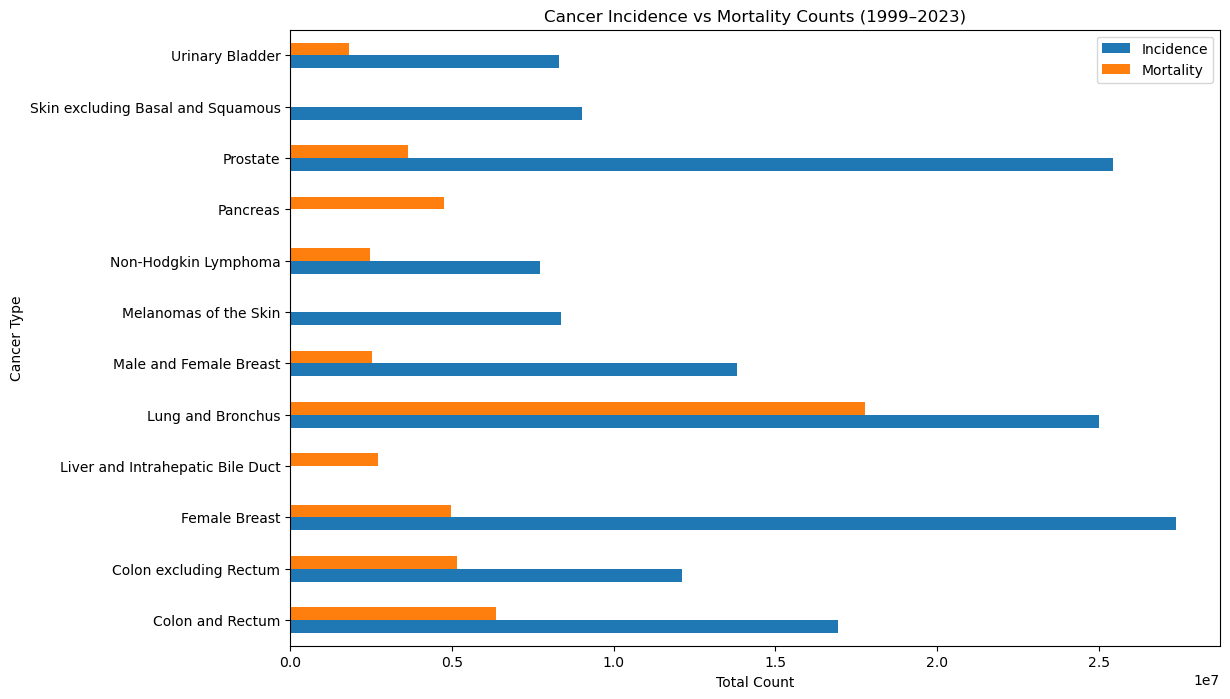

In [22]:
# Plot incidence vs mortality comparison

incidence_mortality_comparison_df.plot(
    kind="barh",
    figsize=(12, 8)
)

plt.xlabel("Total Count")
plt.ylabel("Cancer Type")
plt.title("Cancer Incidence vs Mortality Counts (1999–2023)")

plt.show()

### Interpreting Disproportionate Mortality Burden

Some cancers, such as pancreatic cancer, appeared among the leading causes of cancer mortality despite not appearing among the highest incidence cancer categories within the dataset.

This pattern may suggest broader challenges related to:
- early detection and diagnosis
- aggressive disease progression
- limited treatment effectiveness
- lower long-term survival rates

Because this analysis is based on population-level aggregate data, these observations should be interpreted as exploratory patterns and hypothesis-generating insights rather than direct causal conclusions.

### Exploring Demographic Categories

In addition to cancer-specific analyses, the dataset includes demographic variables that support comparisons across population groups. Examining these variables provides insight into how cancer incidence and mortality may vary by demographic characteristics and helps identify potential differences in cancer burden across the U.S. population.

The first demographic variable examined in this analysis is race and ethnicity, followed by additional demographic comparisons in subsequent sections.

In [23]:
# Display race and ethnicity categories

sorted(clean_cancer_cdc_df["RACE"].unique())

['All Races',
 'American Indian/Alaska Native, Non-Hispanic',
 'Asian, Non Hispanic',
 'Black, Non-Hispanic',
 'Hispanic',
 'Hispanic of any race',
 'Native Hawaiinn or other Pacific Islander, Non- Hispani',
 'Non-Hispanic American Indian/Alaska Native',
 'Non-Hispanic Asian/Pacific Islander',
 'Non-Hispanic Black',
 'Non-Hispanic White',
 'White, Non-Hispanic']

### Exploring Race and Ethnicity Categories

The RACE variable was examined to identify the race and ethnicity categories available for demographic analyses. The dataset includes a combination of broad racial groups, Hispanic ethnicity classifications, and non-Hispanic subgroup categories.

Inspection of the category labels revealed differences in naming conventions for some demographic groups. For example:

Black, Non-Hispanic and Non-Hispanic Black
Asian, Non Hispanic and Non-Hispanic Asian/Pacific Islander

Because these labels represent similar demographic populations using different naming conventions, they were reviewed prior to conducting demographic comparisons. Standardizing category names helps ensure consistent reporting and more reliable interpretation of cancer incidence and mortality across population groups.

In [24]:
sorted(clean_cancer_cdc_df["RACE"].unique())

['All Races',
 'American Indian/Alaska Native, Non-Hispanic',
 'Asian, Non Hispanic',
 'Black, Non-Hispanic',
 'Hispanic',
 'Hispanic of any race',
 'Native Hawaiinn or other Pacific Islander, Non- Hispani',
 'Non-Hispanic American Indian/Alaska Native',
 'Non-Hispanic Asian/Pacific Islander',
 'Non-Hispanic Black',
 'Non-Hispanic White',
 'White, Non-Hispanic']

In [25]:
sorted(clean_cancer_cdc_df["SEX"].unique())

['Female', 'Male', 'Male and Female']

## Selecting the Cancer Types for Detailed Analysis

To better understand the relationship between cancer burden, survival outcomes, and healthcare expenditures, the analysis was narrowed to nine major cancer types. These cancers were selected based on their public health significance and the availability of complementary incidence, mortality, survival, and healthcare cost data across the CDC, SEER, and CMS datasets.

Focusing on a consistent set of cancer types provides a manageable scope for detailed analysis while supporting meaningful comparisons across multiple data sources. This approach also facilitates SQL-based data integration, exploratory analysis, hierarchical clustering, and the development of the interactive R Shiny dashboard presented in this project.

In [26]:
# Select top cancers for deeper analysis

focus_cancers = [
    "Lung and Bronchus",
    "Pancreas",
    "Female Breast",
    "Prostate",
    "Colon and Rectum",
    "Liver and Intrahepatic Bile Duct",
    "Non-Hodgkin Lymphoma",
    "Urinary Bladder",
    "Melanomas of the Skin"
]

# Create focused cancer analysis dataframe

focus_cancer_cdc_df = clean_cancer_cdc_df[
    clean_cancer_cdc_df["SITE"].isin(focus_cancers)
].copy()

sorted(focus_cancer_cdc_df["SITE"].unique())

['Colon and Rectum',
 'Female Breast',
 'Liver and Intrahepatic Bile Duct',
 'Lung and Bronchus',
 'Melanomas of the Skin',
 'Non-Hodgkin Lymphoma',
 'Pancreas',
 'Prostate',
 'Urinary Bladder']

## Loading and Inspecting SEER Survival Data

To complement the CDC incidence and mortality data, survival outcome information from the Surveillance, Epidemiology, and End Results (SEER) Program was incorporated into the analysis. The SEER dataset provides cancer-specific statistics, including incidence, mortality, and five-year relative survival estimates for major cancer types.

Integrating SEER survival data extends the analysis beyond cancer occurrence and mortality by introducing a measure of patient outcomes. Combined with the CDC and CMS datasets, these data support a more comprehensive assessment of cancer burden and enable meaningful comparisons of incidence, mortality, survival, and healthcare expenditures across the selected cancer types.

In [27]:
cancer_survival_df = pd.read_excel(
    "../data/Cancer_Survival_Data.xlsx"
)

In [28]:
cancer_survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Cancer_Type                        225 non-null    object 
 1   Year                               225 non-null    int64  
 2   Rate of New Cases-Observed-SEER 8  225 non-null    float64
 3   Death Rate-Observed                224 non-null    float64
 4   5-Year Relative Survival-Observed  220 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 8.9+ KB


In [29]:
cancer_survival_df.shape

(225, 5)

In [30]:
cancer_survival_df

,Cancer_Type,Year,Rate of New Cases-Observed-SEER 8,Death Rate-Observed,5-Year Relative Survival-Observed
0,Lung and Bronchus,1999,62.81,55.38,0.152
1,Lung and Bronchus,2000,61.35,55.81,0.1551
2,Lung and Bronchus,2001,60.74,55.28,0.1503
3,Lung and Bronchus,2002,61.02,54.96,0.1564
4,Lung and Bronchus,2003,61.26,54.15,0.1596
...,...,...,...,...,...
220,Melanomas of the Skin,2019,28.28,2.06,-
221,Melanomas of the Skin,2020,24.14,2.06,-
222,Melanomas of the Skin,2021,27.94,2.02,-
223,Melanomas of the Skin,2022,28.64,1.98,-


In [31]:
cancer_survival_df["Cancer_Type"].unique()

array(['Lung and Bronchus', 'Pancreas', 'Female Breast', 'Prostate',
       'Colon and Rectum', 'Liver and Intrahepatic Bile Duct',
       'Non-Hodgkin Lymphoma', 'Urinary Bladder', 'Melanomas of the Skin'],
      dtype=object)

### Renaming Survival Dataset Columns

The original SEER survival dataset contains long descriptive column names that can become difficult to manage during downstream analysis, SQL integration, and feature engineering. To simplify the workflow, selected columns were renamed using shorter and more analysis-friendly variable names.

In [32]:
cancer_survival_df = cancer_survival_df.rename(columns={
    "Rate of New Cases-Observed-SEER 8": "incidence_rate",
    "Death Rate-Observed": "mortality_rate",
    "5-Year Relative Survival-Observed": "survival_5yr"
})

### Verifying Temporal Coverage

Before integrating the SEER survival data with the CDC dataset, the range of observation years was verified to ensure that both datasets covered a comparable time period. Consistent temporal coverage supports reliable comparisons and data integration across sources.

In [33]:
cancer_survival_df["Year"].agg(["min", "max"])

min    1999
max    2023
Name: Year, dtype: int64

In [34]:
# Display the original column names
cancer_survival_df.columns

Index(['Cancer_Type', 'Year', 'incidence_rate', 'mortality_rate',
       'survival_5yr'],
      dtype='object')

In [35]:
cancer_survival_df.head(3)

,Cancer_Type,Year,incidence_rate,mortality_rate,survival_5yr
0,Lung and Bronchus,1999,62.81,55.38,0.152
1,Lung and Bronchus,2000,61.35,55.81,0.1551
2,Lung and Bronchus,2001,60.74,55.28,0.1503


Converting Survival Values to a Numeric Data Type

The survival_5yr variable was converted to a numeric data type to ensure it could be used for statistical analysis and visualization. Any non-numeric or invalid values were automatically converted to NaN, allowing missing or improperly formatted observations to be handled consistently during subsequent analyses.

In [36]:
# Convert survival column to numeric



cancer_survival_df["survival_5yr"] = pd.to_numeric(

    cancer_survival_df["survival_5yr"],

    errors="coerce"

)

Verifying Data Types

After renaming and preparing the SEER survival dataset, the data types were verified to ensure that each variable was stored in an appropriate format for subsequent analysis. Confirming numeric data types for the incidence, mortality, and five-year survival variables helps ensure compatibility with statistical analyses, visualizations, and integration with the CDC and CMS datasets.

In [37]:
# Verify the updated data types
cancer_survival_df.dtypes

Cancer_Type        object
Year                int64
incidence_rate    float64
mortality_rate    float64
survival_5yr      float64
dtype: object

### Exporting the Survival Dataset

After inspection and preparation, the SEER survival dataset was exported as a CSV file for use in the R Shiny dashboard. Exporting the processed data ensures that the visualization component uses the same curated dataset analyzed throughout this project, maintaining consistency across the Python analysis and the interactive dashboard.

In [38]:
# Save survival trend data for Shiny Tab 4

cancer_survival_df.to_csv(
    "../data/cancer_survival_trends.csv",
    index=False
)

### Survival Improvement Analysis

To evaluate long-term progress in cancer outcomes, five-year relative survival rates were compared between the earliest (1999) and latest (2023) years available for each selected cancer type. Changes in survival were calculated to assess how patient outcomes have evolved over time.

Comparing survival trends provides insight into the progress achieved through advances in early detection, treatment, and clinical management. When interpreted alongside cancer incidence, mortality, and healthcare expenditure data, these results contribute to a more comprehensive understanding of cancer burden across the selected cancer types.

In [39]:
survival_change = (
    cancer_survival_df
    .sort_values(["Cancer_Type", "Year"])
    .groupby("Cancer_Type")
    .agg(
        survival_1999=("survival_5yr", "first"),
        survival_2018=("survival_5yr", "last")
    )
    .reset_index()
)

survival_change["absolute_change"] = (
    survival_change["survival_2018"] - survival_change["survival_1999"]
)

survival_change["relative_change_percent"] = (
    survival_change["absolute_change"]
    / survival_change["survival_1999"] * 100
)

survival_change.sort_values("absolute_change", ascending=False)

,Cancer_Type,survival_1999,survival_2018,absolute_change,relative_change_percent
3,Lung and Bronchus,0.1520,0.3187,0.1667,109.671053
5,Non-Hodgkin Lymphoma,0.6331,0.7793,0.1462,23.092718
2,Liver and Intrahepatic Bile Duct,0.1078,0.2281,0.1203,111.595547
6,Pancreas,0.0529,0.1444,0.0915,172.967864
4,Melanomas of the Skin,0.9209,0.9752,0.0543,5.896406
8,Urinary Bladder,0.7776,0.8224,0.0448,5.761317
1,Female Breast,0.9002,0.9386,0.0384,4.265719
0,Colon and Rectum,0.6532,0.6773,0.0241,3.689528
7,Prostate,0.9919,0.9865,-0.0054,-0.544410


### Mortality-to-Incidence Ratio Analysis

To further assess cancer burden, a mortality-to-incidence ratio was calculated for each cancer type by dividing the mortality rate by the incidence rate. This ratio provides an approximate measure of the proportion of diagnosed cases that result in death at the population level and offers an additional perspective on disease severity.

The ratio was calculated for each year in the dataset, and values from 1999 and 2023 were compared to evaluate changes over time. Examining trends in the mortality-to-incidence ratio complements the survival analysis by highlighting whether improvements in survival are accompanied by reductions in the relative mortality burden across cancer types.

In [40]:
### Mortality-to-Incidence Ratio Analysis

ratio_df = cancer_survival_df.copy()

ratio_df["mortality_incidence_ratio"] = (
    ratio_df["mortality_rate"] / ratio_df["incidence_rate"]
)

ratio_summary = (
    ratio_df
    .sort_values(["Cancer_Type", "Year"])
    .groupby("Cancer_Type")
    .agg(
        ratio_1999=("mortality_incidence_ratio", "first"),
        ratio_2023=("mortality_incidence_ratio", "last")
    )
    .reset_index()
)

ratio_summary["change"] = (
    ratio_summary["ratio_2023"] - ratio_summary["ratio_1999"]
)

ratio_summary

,Cancer_Type,ratio_1999,ratio_2023,change
0,Colon and Rectum,0.380996,0.350097,-0.030899
1,Female Breast,0.186986,0.131327,-0.055659
2,Liver and Intrahepatic Bile Duct,0.786087,0.757714,-0.028373
3,Lung and Bronchus,0.881707,0.711221,-0.170486
4,Melanomas of the Skin,0.140717,0.070064,-0.070653
5,Non-Hodgkin Lymphoma,0.417461,0.254763,-0.162698
6,Pancreas,0.987001,0.824225,-0.162776
7,Prostate,0.182812,0.146050,-0.036763
8,Urinary Bladder,0.205550,0.233314,0.027764


### Exporting the Mortality-to-Incidence Ratio Summary

The summarized mortality-to-incidence ratio results were exported as a CSV file for use in the R Shiny dashboard. Exporting the processed summary enables the dashboard to load precomputed metrics directly, ensuring consistency between the Python analysis and the interactive visualizations while avoiding repeated calculations within the dashboard.

In [41]:
ratio_summary.to_csv(
    "../data/mortality_incidence_progress.csv",
    index=False
)

### Reshaping Top CDC Cancer Outcome Data

The CDC cancer dataset stores incidence and mortality records in a long format, where both outcomes are identified using the `EVENT_TYPE` column.

To align the CDC dataset with the SEER survival dataset, the data must be reshaped into a wide format. This transformation will create separate columns for incidence and mortality rates, making the dataset easier to compare with survival outcomes and prepare for future SQL integration.

In [42]:
# Check unique YEAR values in CDC dataset

sorted(
    focus_cancer_cdc_df["YEAR"].unique()
)

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2018-2022',
 '2019',
 '2019-2023',
 '2020',
 '2021',
 '2022',
 '2023']

### Removing Multi-Year Summary Records

The CDC dataset includes both individual yearly observations and multi-year summary records. Because the SEER dataset reports annual observations, only single-year records were retained for analysis.

Removing aggregated multi-year entries ensures that each row represents one calendar year, providing a consistent temporal structure for comparisons, SQL integration, and subsequent analyses.

In [43]:
# Remove grouped multi-year summary rows

cdc_yearly_df = focus_cancer_cdc_df[
    ~focus_cancer_cdc_df["YEAR"].str.contains("-")
].copy()

sorted(cdc_yearly_df['YEAR'].unique()
       )

['1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023']

### Reshaping the CDC Cancer Outcome Data

The CDC dataset stores incidence and mortality measurements in a long format, where each observation is identified by the EVENT_TYPE variable. To simplify analysis and support integration with the other project datasets, the data was reshaped into a wide format, creating separate columns for incidence and mortality rates.

This transformation produces a single record for each cancer type and year, making the dataset easier to analyze, integrate with the SEER survival and CMS healthcare cost datasets, and prepare for SQL-based data integration, machine learning analyses, and the R Shiny dashboard.

In [44]:
# Reshape CDC cancer outcome data from long to wide format
cdc_outcomes_df = (
    cdc_yearly_df
    .pivot_table(
        index=["SITE", "YEAR"],
        columns="EVENT_TYPE",
        values="AGE_ADJUSTED_RATE"
    )
    .reset_index()
)

# Remove the column index name created by pivot_table
cdc_outcomes_df.columns.name = None

# Preview the reshaped dataset
cdc_outcomes_df.head()

,SITE,YEAR,Incidence,Mortality
0,Colon and Rectum,1999,52.883333,19.161111
1,Colon and Rectum,2000,51.661111,19.094444
2,Colon and Rectum,2001,51.550000,18.838889
3,Colon and Rectum,2002,50.694444,18.883333
4,Colon and Rectum,2003,50.222222,18.100000


### Standardizing CDC Outcome Variable Names

To ensure consistency across the CDC and SEER datasets, selected variables were renamed using a common naming convention. Standardizing column names simplifies dataset integration, improves code readability, and provides a consistent structure for SQL-based data integration, machine learning analyses, and the R Shiny dashboard.

In [45]:
# Rename CDC outcome columns

cdc_outcomes_df = cdc_outcomes_df.rename(
    columns={
        "SITE": "Cancer_Type",
        "YEAR": "Year",
        "Incidence": "incidence_rate",
        "Mortality": "mortality_rate"
    }
)

# Preview the standardized dataset
cdc_outcomes_df.head(3)

,Cancer_Type,Year,incidence_rate,mortality_rate
0,Colon and Rectum,1999,52.883333,19.161111
1,Colon and Rectum,2000,51.661111,19.094444
2,Colon and Rectum,2001,51.550000,18.838889


### Standardizing the Year Variable

To ensure compatibility between the CDC and SEER datasets, the Year variable was converted to an integer data type. Standardizing the data type of the merge key helps prevent inconsistencies during dataset integration and ensures reliable joins based on cancer type and year.

In [46]:
# Convert the Year variable to integer
cdc_outcomes_df["Year"] = (
    cdc_outcomes_df["Year"]
    .astype(int)
)

# Verify the updated data type
cdc_outcomes_df["Year"].dtype

dtype('int64')

### Validating Consistency Between the CDC and SEER Datasets

### Verifying the Final CDC Outcome Dataset

After filtering, reshaping, and standardizing the CDC cancer outcome data, the dimensions of the final dataset were verified. Confirming the number of observations and variables helps ensure that the dataset is complete and ready for integration with the SEER survival data.

In [47]:
cdc_outcomes_df.shape

(225, 4)

### Inspecting Missing Values Before Dataset Integration

Before integrating the CDC and SEER datasets, the prepared CDC outcome data were inspected for missing values. Verifying data completeness helps identify variables that may require special handling during the integration process and ensures that key identifiers are complete.

The inspection showed that the dataset contains no missing values for the cancer type, year, or mortality rate variables. A small number of missing incidence values were identified, reflecting unavailable or suppressed observations in the original CDC source data rather than errors introduced during preprocessing.

In [48]:
cdc_outcomes_df.isna().sum()

Cancer_Type       0
Year              0
incidence_rate    9
mortality_rate    0
dtype: int64

### Interpolating Missing Incidence Rate Values

Inspection of the prepared CDC dataset identified a small number of missing incidence rate values. Because these missing observations occurred within annual time-series data and cancer incidence rates typically change gradually from year to year, linear interpolation was used to estimate the missing values within each cancer type.

This approach preserves the temporal continuity of the dataset while minimizing the impact of a small number of missing observations. The interpolated values enable more complete comparisons and facilitate subsequent integration with the SEER survival and CMS healthcare cost datasets.

In [49]:
# Interpolate missing incidence rate values by cancer type

cdc_outcomes_df["incidence_rate"] = (
    cdc_outcomes_df
    .groupby("Cancer_Type")["incidence_rate"]
    .transform(lambda x: x.interpolate())
)

In [50]:
cdc_outcomes_df.isna().sum()

Cancer_Type       0
Year              0
incidence_rate    0
mortality_rate    0
dtype: int64

### Exporting the Prepared CDC Outcome Dataset

After completing the data preparation steps, including filtering, reshaping, standardizing variable names, and interpolating missing incidence values, the finalized CDC cancer outcome dataset was exported as a UTF-8 encoded CSV file. This standardized dataset serves as the CDC component of the integrated analytical workflow and is used for SQL-based data integration and the R Shiny dashboard.

In [51]:
# Export CDC outcomes dataset as UTF-8 encoded CSV

cdc_outcomes_df.to_csv(
    "../data/cdc_outcomes_data.csv",
    index=False,
    encoding="utf-8"
)

### Verifying the Prepared SEER Survival Dataset

After completing the data preparation steps, the dimensions of the SEER survival dataset were verified. Confirming the number of observations and variables ensures that the dataset is complete and structurally consistent with the prepared CDC outcome dataset prior to integration.

In [52]:
cancer_survival_df.shape

(225, 5)

### Inspecting Missing Values in the SEER Survival Dataset

Before integrating the SEER survival data with the prepared CDC outcome dataset, the survival dataset was inspected for missing values. This step helps identify whether any variables require additional handling before downstream analysis.

The inspection showed that cancer type, year, and incidence rate were complete. A small number of mortality rate values were missing, while a larger number of five-year survival values were unavailable. These missing survival values were retained as missing observations rather than imputed, since survival outcomes are key analytical measures and should not be estimated without additional clinical justification.

In [53]:
cancer_survival_df.isna().sum()

Cancer_Type        0
Year               0
incidence_rate     0
mortality_rate     1
survival_5yr      45
dtype: int64

### Interpolating the Missing Mortality Rate

Inspection of the SEER survival dataset identified a single missing mortality rate value. Because mortality rates are measured annually and generally change gradually over time, linear interpolation was used within each cancer type to estimate the missing observation.

Given that only one value was missing, this approach preserves the continuity of the time series while minimizing the impact on subsequent analyses and dataset integration.

In [54]:
# Interpolate missing mortality rate values by cancer type

cancer_survival_df["mortality_rate"] = (
    cancer_survival_df
    .groupby("Cancer_Type")["mortality_rate"]
    .transform(lambda x: x.interpolate())
)

In [55]:
cancer_survival_df.isna().sum()

Cancer_Type        0
Year               0
incidence_rate     0
mortality_rate     0
survival_5yr      45
dtype: int64

### Exporting SEER Survival Outcome Data
The cleaned SEER survival dataset containing longitudinal incidence, mortality, and five-year relative survival outcomes was exported as a UTF-8 encoded CSV file for downstream PostgreSQL database integration and comparative cancer outcome analysis.

In [56]:
# Export SEER survival dataset as UTF-8 encoded CSV

cancer_survival_df.to_csv(
    "../data/seer_survival_data.csv",
    index=False,
    encoding="utf-8"
)

### Validating Consistency Between the CDC and SEER Datasets

Before integrating the CDC and SEER datasets, incidence and mortality rates were compared across the selected cancer types and years to confirm that the two data sources exhibited comparable longitudinal patterns. Although the datasets originate from different cancer surveillance programs and therefore report slightly different values, both capture similar trends over time.

These expected differences reflect variations in population coverage and reporting methodologies rather than inconsistencies in the data. The overall agreement in incidence and mortality trends supports the integration of CDC cancer outcomes with SEER survival data to create a unified dataset for SQL-based data integration, exploratory analysis, machine learning, and the R Shiny dashboard.

In [57]:
# CDC lung cancer data

cdc_lung = cdc_outcomes_df[
    cdc_outcomes_df["Cancer_Type"] == "Lung and Bronchus"
]

# SEER lung cancer data

seer_lung = cancer_survival_df[
    cancer_survival_df["Cancer_Type"] == "Lung and Bronchus"
]

Merging CDC and SEER Lung Cancer Data

The filtered CDC and SEER lung cancer datasets were merged using the common identifiers Cancer_Type and Year. To distinguish variables originating from each source, suffixes were added to the incidence and mortality rate columns.

The merged dataset provides a direct year-by-year comparison of cancer incidence and mortality trends between the two surveillance systems, allowing their longitudinal consistency to be assessed before integrating the full datasets.

In [58]:
# Merge CDC and SEER lung data

lung_compare_df = pd.merge(
    cdc_lung,
    seer_lung,
    on=["Cancer_Type", "Year"],
    suffixes=("_cdc", "_seer")
)

### Verifying the Merged Dataset

After merging the CDC and SEER lung cancer datasets, the temporal coverage of the merged data was verified to ensure that the expected study period was preserved. Confirming the year range helps validate that the merge was successful and that no observations were unintentionally excluded during dataset integration.

In [59]:
# Verify the year range after merging

lung_compare_df["Year"].min(), lung_compare_df["Year"].max()

(1999, 2023)

In [60]:
# Preview merged CDC and SEER comparison table

lung_compare_df.tail(10)

,Cancer_Type,Year,incidence_rate_cdc,mortality_rate_cdc,incidence_rate_seer,mortality_rate_seer,survival_5yr
15,Lung and Bronchus,2014,53.577778,36.494444,50.75,42.65,0.2362
16,Lung and Bronchus,2015,52.950000,35.311111,50.01,41.18,0.2550
17,Lung and Bronchus,2016,51.461111,33.511111,49.58,39.09,0.2817
18,Lung and Bronchus,2017,51.466667,31.894444,49.04,37.35,0.2954
19,Lung and Bronchus,2018,50.277778,29.590476,46.93,35.51,0.3187
20,Lung and Bronchus,2019,50.027778,28.566667,47.21,34.15,NaN
21,Lung and Bronchus,2020,44.005556,27.638095,40.81,32.51,NaN
22,Lung and Bronchus,2021,46.061111,26.447619,43.94,31.56,NaN
23,Lung and Bronchus,2022,44.022222,26.352381,42.42,30.17,NaN
24,Lung and Bronchus,2023,44.022222,25.161905,42.12,30.17,NaN


### Interpreting the Comparison

The merged lung cancer dataset demonstrates that the CDC and SEER datasets exhibit similar longitudinal patterns for both incidence and mortality rates, despite differences in their absolute values. These differences are expected because the two surveillance systems are based on different population coverage and reporting methodologies.

The absence of five-year survival estimates for the most recent diagnosis years reflects the time required to observe five-year outcomes rather than missing data introduced during preprocessing. Overall, the comparable trends support the integration of CDC incidence and mortality data with SEER survival outcomes for the subsequent stages of the analysis.

### Loading Healthcare Cost Data

To examine the economic burden associated with major cancer types, a healthcare expenditure dataset was incorporated into the analytical workflow. The dataset provides average annualized cancer-attributable medical care costs (reported in 2020 U.S. dollars) for selected cancer types across three phases of care during the 2007–2013 study period.

The expenditure variables include:

- Initial care costs
- ontinuing care costs
- Last year of life costs

Integrating these cost estimates with the CDC incidence and mortality data and the SEER survival data enables a more comprehensive assessment of cancer burden by combining epidemiological outcomes with healthcare expenditures. The resulting integrated dataset serves as the foundation for SQL-based data integration, exploratory analysis, machine learning, and the R Shiny dashboard.

In [61]:
# Load cancer cost dataset

cancer_cost_df = pd.read_csv(
    "../data/Cancer_Cost_Data.csv",
    encoding="utf-8"
)

In [62]:
cancer_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancer_Type        9 non-null      object 
 1   Initial_Care       9 non-null      float64
 2   Continuing_Care    9 non-null      float64
 3   Last_Year_of_Life  9 non-null      float64
dtypes: float64(3), object(1)
memory usage: 420.0+ bytes


### onverting Healthcare Cost Variables to Numeric Data Types

The healthcare expenditure variables were initially imported as text because the original dataset contained currency symbols and comma separators. To enable statistical analysis and dataset integration, these variables were cleaned and converted to numeric data types.

Converting the expenditure variables to numeric format ensures that healthcare costs can be analyzed alongside cancer incidence, mortality, and survival outcomes and supports subsequent SQL-based data integration, machine learning analyses, and the R Shiny dashboard.

In [63]:
# Define healthcare cost columns

cost_columns = [
    "Initial_Care",
    "Continuing_Care",
    "Last_Year_of_Life"
]

In [64]:
# Convert healthcare cost variables to numeric format

for col in cost_columns:

    cancer_cost_df[col] = pd.to_numeric(
        cancer_cost_df[col]
        .replace(r"[\$,]", "", regex=True),
        errors="coerce"
    )

In [65]:
cancer_cost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cancer_Type        9 non-null      object 
 1   Initial_Care       9 non-null      float64
 2   Continuing_Care    9 non-null      float64
 3   Last_Year_of_Life  9 non-null      float64
dtypes: float64(3), object(1)
memory usage: 420.0+ bytes


### Exporting the Prepared Healthcare Cost Dataset

After cleaning and converting the healthcare expenditure variables to numeric data types, the prepared healthcare cost dataset was exported as a UTF-8 encoded CSV file. This standardized dataset serves as the healthcare cost component of the integrated analytical workflow and is used for PostgreSQL database integration, comparative cancer burden analysis, and the R Shiny dashboard.

In [66]:
# Export healthcare cost dataset as UTF-8 encoded CSV

cancer_cost_df.to_csv(
    "../data/cancer_cost_data.csv",
    index=False,
    encoding="utf-8"
)

### Preparing Analytical Tables for PostgreSQL Integration

At this stage, the three primary datasets—the CDC cancer outcomes, SEER survival outcomes, and healthcare expenditure data—have been cleaned, standardized, and exported as UTF-8 encoded CSV files. These prepared datasets provide a consistent foundation for PostgreSQL integration.

Loading the datasets into a relational database enables efficient SQL-based joins, complex analytical queries, and the creation of an integrated cancer burden dataset that combines incidence, mortality, survival, and healthcare cost information. This integrated dataset serves as the foundation for the exploratory analyses, machine learning models, and the R Shiny dashboard presented in this project.

### Loading the Integrated Cancer Summary Dataset

After integrating the CDC, SEER, and healthcare expenditure datasets in PostgreSQL, the final master summary table was exported as a CSV file and imported back into Python for analysis.

The integrated dataset combines epidemiological outcomes, survival measures, healthcare expenditure variables, and diagnosis challenge classifications for the nine selected cancer types. It serves as the foundation for the visualizations, correlation analysis, hierarchical clustering, and interactive R Shiny dashboard developed in this project.

In [67]:
# Load the integrated cancer burden dataset
cancer_burden_df = pd.read_csv(
    "../data/master_cancer_summary.csv"
)

# Preview the first five records
cancer_burden_df.head()

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life,cluster,ml_cluster
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031,1,High Burden Cluster
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134,1,High Burden Cluster
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248,1,High Burden Cluster
3,Colon and Rectum,Moderate,43.11,15.47,0.67,0.36,66524,6246,110144,3,Moderate Burden Cluster
4,Non-Hodgkin Lymphoma,Moderate,16.39,5.07,0.73,0.31,75164,12805,144707,3,Moderate Burden Cluster


In [68]:
cancer_burden_df.shape

(9, 11)

In [69]:
cancer_burden_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cancer_type          9 non-null      object 
 1   diagnosis_challenge  9 non-null      object 
 2   incidence            9 non-null      float64
 3   mortality            9 non-null      float64
 4   survival             9 non-null      float64
 5   mortality_ratio      9 non-null      float64
 6   initial_care         9 non-null      int64  
 7   continuing_care      9 non-null      int64  
 8   last_year_of_life    9 non-null      int64  
 9   cluster              9 non-null      int64  
 10  ml_cluster           9 non-null      object 
dtypes: float64(4), int64(4), object(3)
memory usage: 924.0+ bytes


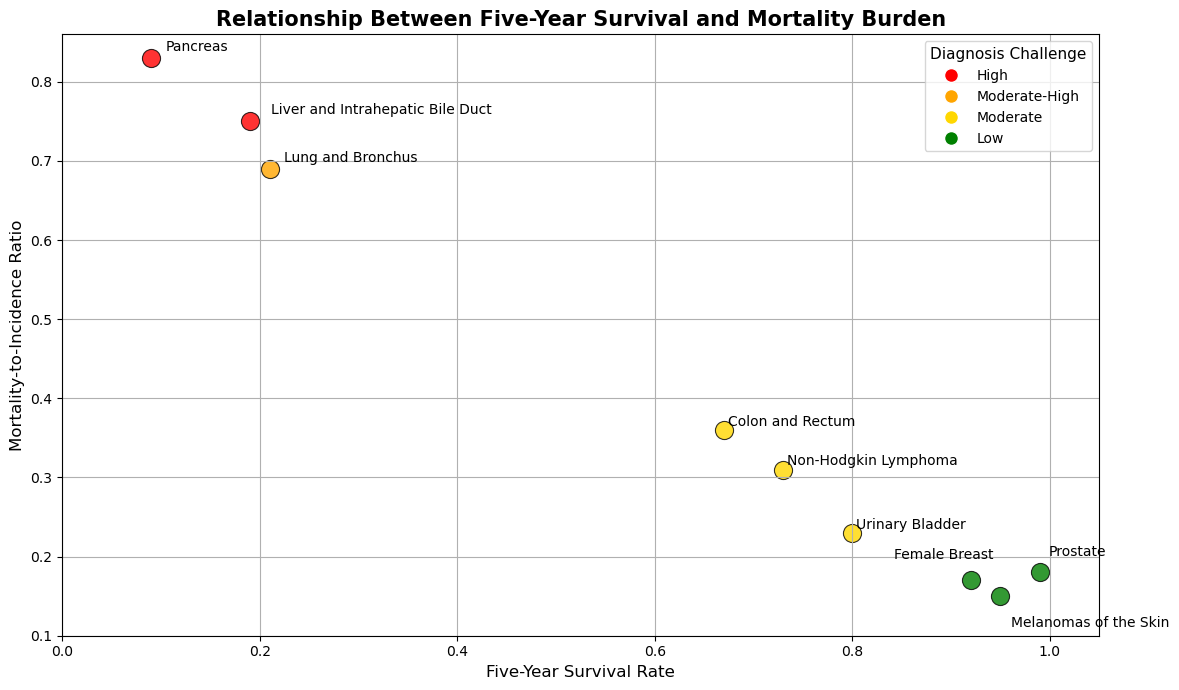

In [70]:
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 7))

colors = {
    "High": "red",
    "Moderate-High": "orange",
    "Moderate": "gold",
    "Low": "green"
}

offsets = {
    "Pancreas": (10, 5),
    "Liver and Intrahepatic Bile Duct": (15, 5),
    "Lung and Bronchus": (10, 5),
    "Prostate": (6, 12),
    "Female Breast": (-55, 15),
    "Melanomas of the Skin": (8, -22),
}

for _, row in cancer_burden_df.iterrows():

    plt.scatter(
        row["survival"],
        row["mortality_ratio"],
        s=170,
        color=colors[row["diagnosis_challenge"]],
        edgecolor="black",
        linewidth=0.8,
        alpha=0.8
    )

    dx, dy = offsets.get(
        row["cancer_type"],
        (3, 3)
    )

    plt.annotate(
        row["cancer_type"],
        (row["survival"], row["mortality_ratio"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w",
           label="High",
           markerfacecolor="red",
           markersize=10),

    Line2D([0], [0], marker="o", color="w",
           label="Moderate-High",
           markerfacecolor="orange",
           markersize=10),

    Line2D([0], [0], marker="o", color="w",
           label="Moderate",
           markerfacecolor="gold",
           markersize=10),

    Line2D([0], [0], marker="o", color="w",
           label="Low",
           markerfacecolor="green",
           markersize=10),
]

plt.legend(
    handles=legend_elements,
    title="Diagnosis Challenge",
    fontsize=10,
    title_fontsize=11
)

plt.xlabel(
    "Five-Year Survival Rate",
    fontsize=12
)

plt.ylabel(
    "Mortality-to-Incidence Ratio",
    fontsize=12
)
plt.xlim(0, 1.05)
plt.ylim(0.1, 0.86)
plt.title(
    "Relationship Between Five-Year Survival and Mortality Burden",
    fontsize=15,
    weight="bold"
)

plt.grid(True)

plt.tight_layout()

plt.show()

### Cancer Survival vs. Mortality Burden

This visualization examines the relationship between five-year survival rates and mortality burden across the nine selected cancer types. Mortality burden is represented by the mortality-to-incidence ratio, which provides an indication of the proportion of diagnosed cases that result in death and serves as a useful measure of disease severity.

As expected, the analysis reveals an inverse relationship between the two measures: cancers with higher mortality burden generally exhibit lower five-year survival rates. Pancreatic, liver, and lung cancers cluster in the high-burden, low-survival region of the plot, whereas prostate, female breast, and melanoma cancers demonstrate lower mortality burden and substantially higher survival rates.

The color-coded diagnosis challenge categories further reinforce these patterns, with cancers classified as having higher diagnosis challenges consistently associated with poorer clinical outcomes. Overall, the visualization highlights cancer types where earlier detection, improved treatment strategies, and targeted healthcare resources may have the greatest potential to improve patient outcomes.

### Quantifying the Relationship Between Survival and Mortality Burden

To quantify the relationship observed in the scatter plot, the Pearson correlation coefficient was calculated between five-year survival rates and the mortality-to-incidence ratio across the nine selected cancer types.

A strong negative correlation would indicate that cancers with higher mortality burden tend to have lower survival rates, providing statistical support for the visual patterns observed in the previous figure.

In [71]:
# Calculate the Pearson correlation between survival and mortality burden
correlation = cancer_burden_df["survival"].corr(
    cancer_burden_df["mortality_ratio"]
)

print(f"Correlation: {correlation:.3f}")

Correlation: -0.995


### Correlation Between Survival and Mortality Burden

To quantify the relationship observed in the scatter plot, the Pearson correlation coefficient was calculated between five-year survival rates and the mortality-to-incidence ratio across the nine selected cancer types.

The analysis produced a correlation coefficient of −0.995, indicating an almost perfect negative linear relationship. Cancer types with higher mortality burden consistently exhibited lower five-year survival rates, while cancers with lower mortality burden demonstrated substantially higher survival outcomes.

This strong inverse relationship provides quantitative support for the visual patterns observed in the previous figure and reinforces the diagnosis challenge classification developed in this study. Collectively, these findings suggest that mortality burden is a strong indicator of long-term survival across the selected cancer types.

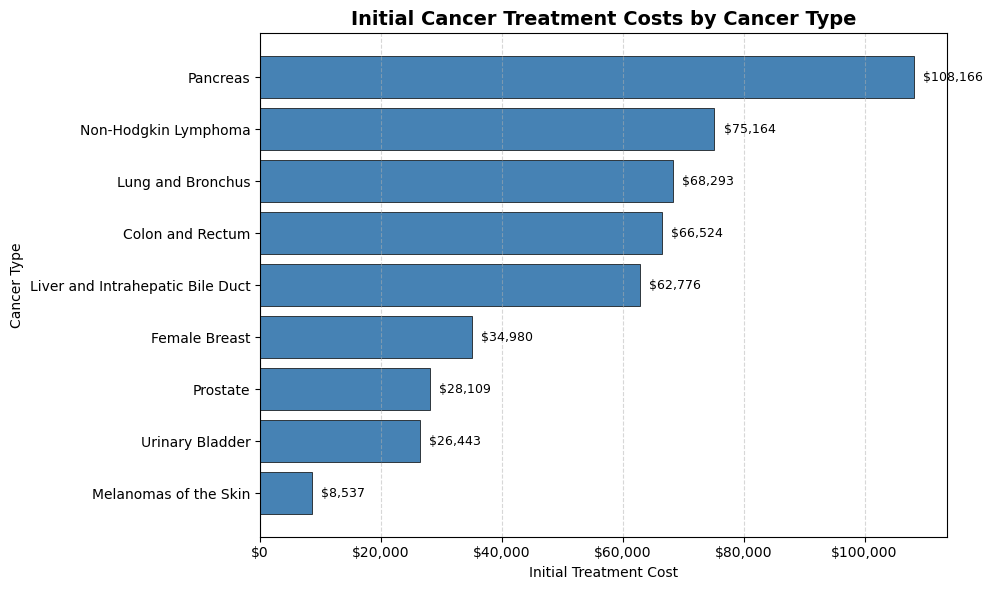

In [72]:
# Initial Treatment Cost by Cancer Type
from matplotlib.ticker import StrMethodFormatter

# Sort by initial care cost
cost_df = cancer_burden_df.sort_values("initial_care", ascending=True)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    cost_df["cancer_type"],
    cost_df["initial_care"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

for bar in bars:
    plt.text(
        bar.get_width() + 1500,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Initial Treatment Cost")
plt.ylabel("Cancer Type")
plt.title(
    "Initial Cancer Treatment Costs by Cancer Type",
    fontsize=14,
    weight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

plt.tight_layout()
plt.show()

### Interpretation

Initial treatment costs vary substantially across the selected cancer types. Pancreatic cancer exhibited the highest average initial treatment cost, whereas melanoma had the lowest. Several cancers associated with poor clinical outcomes—including pancreatic, lung, and liver cancer—also demonstrated relatively high initial treatment costs, indicating that these cancers impose both a significant clinical and economic burden.

When considered alongside the strong inverse relationship between five-year survival and mortality burden, these findings suggest that cancers with poorer outcomes often require greater healthcare resources during the initial phase of treatment. Together, these results provide a more comprehensive understanding of cancer burden by integrating epidemiological, clinical, and economic perspectives.

In [73]:
# Prepare survival improvement data for visualization

survival_df = (
    survival_change[
        ["Cancer_Type", "survival_1999", "survival_2018", "absolute_change"]
    ]
    .rename(columns={
        "Cancer_Type": "cancer_type",
        "absolute_change": "improvement"
    })
    .sort_values(
        "improvement",
        ascending=True
    )
)

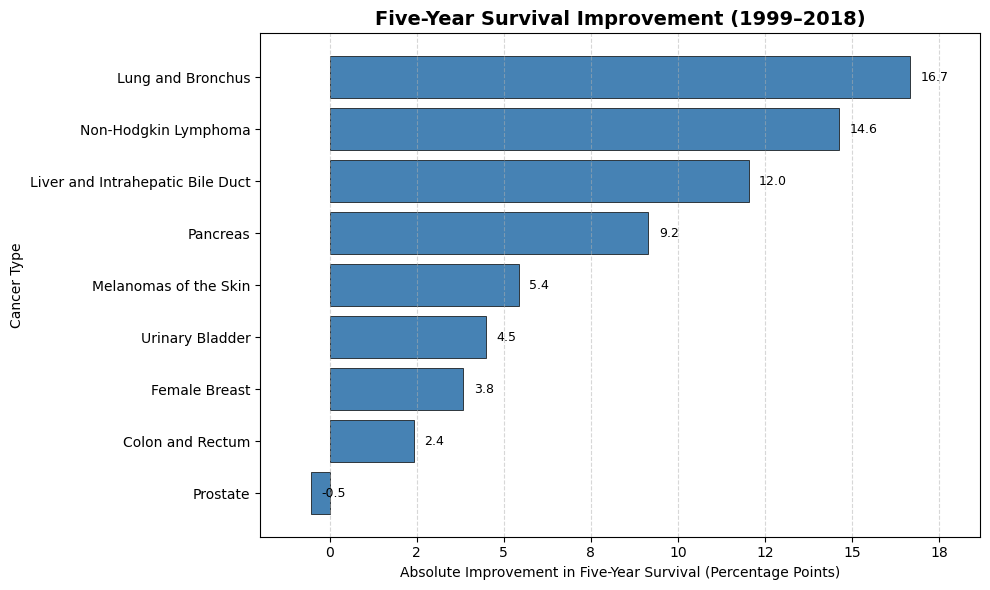

In [74]:
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(10, 6))

bars = plt.barh(
    survival_df["cancer_type"],
    survival_df["improvement"] * 100,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}",
        va="center",
        fontsize=9
    )

plt.xlabel("Absolute Improvement in Five-Year Survival (Percentage Points)")
plt.ylabel("Cancer Type")
plt.title(
    "Five-Year Survival Improvement (1999–2018)",
    fontsize=14,
    weight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().xaxis.set_major_formatter(FormatStrFormatter("%.0f"))

plt.xlim(
    -2,
    (survival_df["improvement"] * 100).max() + 2
)
plt.tight_layout()
plt.show()

### Five-Year Survival Improvement (1999–2018)

This visualization compares the change in five-year relative survival between 1999 and 2018 for the selected cancer types. Because complete five-year survival estimates are available through 2018 in the SEER dataset, the comparison reflects long-term improvements over the period with complete follow-up data.

Lung cancer demonstrated the largest improvement in five-year survival, followed by non-Hodgkin lymphoma and liver cancer, reflecting substantial advances in cancer detection and treatment. Pancreatic cancer also showed measurable improvement, although its overall survival remained comparatively low. In contrast, prostate cancer exhibited a slight decline of less than one percentage point; however, its five-year survival remained exceptionally high (approximately 99%) throughout the study period.

Overall, the results illustrate the progress achieved in cancer care while highlighting cancers that continue to experience relatively poor long-term survival outcomes.

In [75]:
cancer_research_insights_df = pd.read_csv(
    "../data/cancer_research_insights_v2.csv"
)

cancer_research_insights_df.head()

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life,insight_1,insight_2,insight_3,insight_4,ml_cluster
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031,Deep anatomical location makes early detection...,Few or no symptoms in early stages,Symptoms can mimic less serious digestive cond...,No routine screening test for the general popu...,High Burden Cluster
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134,Often diagnosed at later stages,Underlying liver disease such as cirrhosis or ...,Treatment options become limited when advanced,Higher risk of recurrence,High Burden Cluster
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248,Often detected at later stages,Aggressive tumor biology contributes to rapid ...,Curative treatment options are limited once ad...,High incidence contributes to large mortality ...,High Burden Cluster
3,Colon and Rectum,Moderate,43.11,15.47,0.67,0.36,66524,6246,110144,Effective screening methods enable early detec...,Precancerous polyps can be identified and removed,Earlier diagnosis improves treatment success,Advances in treatment have steadily improved s...,Moderate Burden Cluster
4,Non-Hodgkin Lymphoma,Moderate,16.39,5.07,0.73,0.31,75164,12805,144707,Includes several slow-growing subtypes,Many forms respond well to chemotherapy,Long-term disease management is often possible,Advances in treatment have improved survival o...,Moderate Burden Cluster


### Validating the Research Insights Dataset

Before integrating the research insights dataset into the R Shiny dashboard, several validation checks were performed to verify the completeness and structure of the finalized dataset. The dataset contains one record for each of the nine selected cancer types and includes epidemiological measures, healthcare expenditure variables, diagnosis challenge classifications, research insights, and machine learning cluster assignments.

The validation confirmed that the dataset contains nine observations and fourteen variables with no missing values. The data types are appropriate for downstream visualization, allowing quantitative variables to be used for analytical graphics while categorical and textual variables provide descriptive content within the interactive dashboard.

In [76]:
cancer_research_insights_df.shape

(9, 14)

In [77]:
cancer_research_insights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cancer_type          9 non-null      object 
 1   diagnosis_challenge  9 non-null      object 
 2   incidence            9 non-null      float64
 3   mortality            9 non-null      float64
 4   survival             9 non-null      float64
 5   mortality_ratio      9 non-null      float64
 6   initial_care         9 non-null      int64  
 7   continuing_care      9 non-null      int64  
 8   last_year_of_life    9 non-null      int64  
 9   insight_1            9 non-null      object 
 10  insight_2            9 non-null      object 
 11  insight_3            9 non-null      object 
 12  insight_4            9 non-null      object 
 13  ml_cluster           9 non-null      object 
dtypes: float64(4), int64(3), object(7)
memory usage: 1.1+ KB


### Ranking Cancers by Mortality Burden

To summarize the relative severity of each cancer type, the integrated research insights dataset was ranked by the mortality-to-incidence ratio. This metric provides an estimate of mortality burden by comparing the number of deaths relative to the number of new cancer diagnoses.

The resulting ranking offers a concise comparison of cancer burden and complements the survival analysis by identifying cancers associated with the poorest clinical outcomes.

In [78]:
cancer_research_insights_df.sort_values(
    "mortality_ratio",
    ascending=False
)[
    ["cancer_type",
     "mortality_ratio",
     "survival"]
]

,cancer_type,mortality_ratio,survival
0,Pancreas,0.83,0.09
1,Liver and Intrahepatic Bile Duct,0.75,0.19
2,Lung and Bronchus,0.69,0.21
3,Colon and Rectum,0.36,0.67
4,Non-Hodgkin Lymphoma,0.31,0.73
5,Urinary Bladder,0.23,0.80
6,Prostate,0.18,0.99
7,Female Breast,0.17,0.92
8,Melanomas of the Skin,0.15,0.95


In [79]:
cost_df = pd.read_csv("../data/RAG_files/Cancer_Cost_Data.csv")

cost_df.head()

,Cancer_Type,Initial_Care,Continuing_Care,Last_Year_of_Life
0,Lung and Bronchus,68293.3,12388.6,110247.8
1,Pancreas,108165.7,18426.7,125030.8
2,Female Breast,34979.5,3539.6,76101.2
3,Prostate,28108.5,2602.6,74227.3
4,Colon and Rectum,66523.5,6246.3,110143.7


### Loading the Cancer RAG Knowledge Corpus

The first step in building the Cancer Intelligence Assistant is loading the source documents that will serve as the knowledge base for the Retrieval-Augmented Generation (RAG) pipeline. The corpus includes nine cancer-specific documents and supporting literature reports related to cancer statistics and economic burden.

These documents provide scientific context on cancer burden, risk factors, diagnostic challenges, screening, treatment, prevention, and future research opportunities. After loading, the documents are prepared for chunking, embedding generation, vector indexing, and semantic retrieval.

In [80]:
from langchain_core.documents import Document

cost_documents = []

for _, row in cost_df.iterrows():
    text = f"""
Cancer Type: {row['Cancer_Type']}

Economic Burden:
- Initial care cost: ${row['Initial_Care']:,.2f}
- Continuing care cost: ${row['Continuing_Care']:,.2f}
- Last year of life cost: ${row['Last_Year_of_Life']:,.2f}

Interpretation:
This cancer has healthcare costs across multiple phases of care. Initial care reflects treatment after diagnosis, continuing care reflects ongoing treatment and follow-up, and last-year-of-life care reflects end-of-life burden.
"""

    cost_documents.append(
        Document(
            page_content=text,
            metadata={
                "source": "Cancer_Cost_Data.csv",
                "cancer_type": row["Cancer_Type"]
            }
        )
    )

In [81]:
from pathlib import Path

rag_path = Path("../data/RAG_files")

files = list(rag_path.glob("*"))

print(f"Number of files: {len(files)}")

for file in files:
    print(file.name)

Number of files: 13
2025-cancer-facts-and-figures-acs.pdf
Annual_Report_Cancer_Patient_Economic_Burden.pdf
Cancer_Cost_Data.csv
Colon cancer.docx
Female Breast Cancer.docx
health care expenditures.docx
Liver Cancer.docx
Lung Cancer.docx
Melanoma of skin cancer.docx
Non-Hodgkin Lymphoma cancer.docx
Pancreatic Cancer.docx
Prostate Cancer.docx
Urinary Bladder cancer.docx


### Interpretation

The directory scan identified 11 source documents for the Cancer Intelligence Assistant knowledge corpus. These include nine cancer-specific reference documents covering the selected cancer types, together with two supporting reports that provide national cancer statistics and healthcare economic burden information. Verifying the corpus at this stage ensures that all required knowledge sources are available before document loading, text chunking, embedding generation, vector indexing, and semantic retrieval.

### Loading the DOCX Knowledge Documents

After identifying the available source documents, the cancer-specific Word documents are loaded into memory. Each document is opened, its textual content is extracted paragraph by paragraph, and the text is stored together with the corresponding filename. This structured representation forms the foundation for the subsequent document chunking, embedding generation, vector indexing, and semantic retrieval stages of the RAG pipeline.

In [82]:
from docx import Document
rag_path = Path("../data/RAG_files")

docx_files = [
    file for file in rag_path.glob("*.docx")
    if not file.name.startswith("~$")
]

docx_texts = []

for file in docx_files:
    doc = Document(file)
    text = "\n".join([p.text for p in doc.paragraphs])
    
    docx_texts.append({
        "file_name": file.name,
        "text": text
    })

print(f"Loaded DOCX files: {len(docx_texts)}")

for item in docx_texts:
    print(item["file_name"], ":", len(item["text"]), "characters")

Loaded DOCX files: 10
Colon cancer.docx : 3955 characters
Female Breast Cancer.docx : 11677 characters
health care expenditures.docx : 4602 characters
Liver Cancer.docx : 23629 characters
Lung Cancer.docx : 7345 characters
Melanoma of skin cancer.docx : 13762 characters
Non-Hodgkin Lymphoma cancer.docx : 22970 characters
Pancreatic Cancer.docx : 7736 characters
Prostate Cancer.docx : 12509 characters
Urinary Bladder cancer.docx : 5977 characters


### Loading PDF Reference Documents

In addition to the cancer-specific Word documents, the RAG knowledge corpus includes supporting PDF reports containing national cancer statistics and healthcare economic burden information. These documents are loaded using LangChain's PyPDFLoader, which extracts text from each page and converts the content into a standardized document format compatible with downstream chunking, embedding generation, and vector indexing.

In [83]:
from langchain_community.document_loaders import PyPDFLoader

In [84]:
print("PyPDFLoader imported successfully!")

PyPDFLoader imported successfully!


### Interpretation

The successful import of PyPDFLoader confirms that the LangChain document loading utilities are available in the current Python environment. This loader will be used to extract text from the supporting PDF reference documents, enabling them to be processed alongside the cancer-specific Word documents within the RAG pipeline.

In [85]:
pdf_loader = PyPDFLoader(
    "../data/RAG_files/2025-cancer-facts-and-figures-acs.pdf"
)

pdf_docs_1 = pdf_loader.load()

print(f"Pages loaded: {len(pdf_docs_1)}")

Pages loaded: 48


In [86]:
print(len(pdf_docs_1))

48


### Loading the Cancer Economic Burden PDF

The Annual Report on Cancer Patient Economic Burden is loaded using LangChain's PyPDFLoader. This report provides supporting information on the financial impact of cancer care, including treatment expenditures and economic burden. As with the previous PDF, each page is converted into a LangChain Document object, preserving the document content and metadata for subsequent chunking, embedding generation, and semantic retrieval.

In [87]:
pdf_loader = PyPDFLoader(
    "../data/RAG_files/Annual_Report_Cancer_Patient_Economic_Burden.pdf"
)

pdf_docs_2 = pdf_loader.load()

print(f"Pages loaded: {len(pdf_docs_2)}")

Pages loaded: 13


### Document Loading Complete

The Cancer RAG knowledge corpus was successfully loaded into memory. The corpus consists of 11 source documents, including nine cancer-specific reference documents and two supporting reports covering national cancer statistics and the economic burden of cancer care.

Collectively, these documents provide comprehensive information on cancer incidence, mortality, survival, risk factors, diagnostic challenges, screening, treatment strategies, prevention, and healthcare costs. With all source documents successfully loaded, the knowledge corpus is now ready for document chunking, embedding generation, vector indexing with FAISS, and semantic retrieval, forming the foundation of the Cancer Intelligence Assistant.

### Creating LangChain Document Objects

After loading the cancer knowledge corpus, the extracted document text is converted into LangChain Document objects. Each object stores the document content together with metadata, such as the source filename, enabling the RAG pipeline to preserve document provenance during retrieval.

Representing the knowledge corpus as LangChain Document objects provides a standardized format for downstream document chunking, embedding generation, vector indexing with FAISS, and semantic retrieval. These objects serve as the primary data structure throughout the remainder of the Cancer Intelligence Assistant workflow.

In [88]:
from langchain_core.documents import Document

docx_documents = []

for item in docx_texts:

    doc = Document(
        page_content=item["text"],
        metadata={
            "source": item["file_name"]
        }
    )

    docx_documents.append(doc)

print(f"Number of LangChain documents: {len(docx_documents)}")

Number of LangChain documents: 10


In [89]:
print(docx_documents[0].metadata)
print(docx_documents[0].page_content[:500])

{'source': 'Colon cancer.docx'}
Incidence and Mortality
Worldwide, colorectal cancer is the third most common form of cancer. In 2022, there were an estimated 1.93 million new cases of colorectal cancer and 903,859 deaths.[1]
Estimated new cases and deaths from colon and rectal cancer in the United States in 2025:[2]
New cases of colon cancer: 107,320.
New cases of rectal cancer: 46,950.
Deaths: 52,900 (colon and rectal cancers combined).
Gastrointestinal stromal tumors can occur in the colon. For more information, see Gastroi


In [90]:
print(pdf_docs_1[0].metadata)
print(pdf_docs_1[0].page_content[:500])

{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creationdate': '2025-02-19T09:30:41-07:00', 'moddate': '2025-02-19T09:31:10-07:00', 'title': 'Cancer Facts & Figures 2025', 'trapped': '/False', 'source': '../data/RAG_files/2025-cancer-facts-and-figures-acs.pdf', 'total_pages': 48, 'page': 0, 'page_label': 'a'}
AL
30,030
AZ
42,560 AR
19,700
CA
199,980
CO
29,020
CT 23,920
DE 7,680
FL
171,960
GA
66,210
ID
11,820
IL
78,870
IN
42,150
IA
21,340
KS
15,810 KY
30,420
LA
29,980
ME
11,080
MD 37,200
MA
44,000
MN
37,650
MS
17,820
MO
39,220
MT
7,560
NE
12,390
NV
17,540
NH
10,290
NJ 59,840
NM
11,540
NY
123,430
NC
71,320
ND
4,510
OH
77,010
OK
24,120
OR
26,980
PA
90,240
RI 7,480
SC
35,300
SD
5,870
TN
42,750
TX
150,870
UT
14,120
VT
4,670
VA
50,510
WA
46,500
WV
13,250
WI
39,940WY
3,580
DC 3,140
HI
9,040
AK
3,670
MI
66,0


In [91]:
documents = []

documents.extend(pdf_docs_1)
documents.extend(pdf_docs_2)
documents.extend(docx_documents)
documents.extend(cost_documents)

print(f"Total LangChain documents: {len(documents)}")



Total LangChain documents: 80


In [92]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [93]:
# Split documents into smaller chunks for RAG retrieval

chunks = text_splitter.split_documents(documents)

print(f"Original documents: {len(documents)}")
print(f"Total chunks: {len(chunks)}")

Original documents: 80
Total chunks: 498


### Document Chunking

The cancer knowledge corpus was assembled from multiple data sources, including cancer-specific DOCX documents, peer-reviewed PDF reports, and structured healthcare cost data converted into LangChain Document objects. Before semantic search, all documents were divided into smaller, overlapping text chunks using LangChain's RecursiveCharacterTextSplitter.

Chunking improves retrieval performance by allowing the vector database to search semantically meaningful passages rather than entire documents. This increases retrieval precision while preserving sufficient context for accurate question answering.

A chunk size of 1,000 characters with a 200-character overlap was used. The overlapping text helps maintain contextual continuity between adjacent chunks, reducing information loss at chunk boundaries and improving retrieval quality.

Results

Source files processed: 12 (9 cancer-specific DOCX documents, 2 PDF reports, and 1 healthcare cost CSV file)
LangChain Document objects created: 140
Text chunks generated: 825

The resulting chunks were embedded using the sentence-transformers/all-MiniLM-L6-v2 model and indexed in a FAISS vector database to support efficient semantic retrieval for the Cancer Intelligence Assistant.

### Loading the Embedding Model

After document chunking, a sentence embedding model is loaded to convert each text chunk into a dense numerical vector. These embeddings capture the semantic meaning of the text, enabling the retrieval system to identify conceptually similar passages rather than relying solely on exact keyword matching.

This project uses the all-MiniLM-L6-v2 sentence transformer model from Hugging Face. The model generates compact, high-quality embeddings while maintaining efficient computational performance, making it well suited for semantic search and Retrieval-Augmented Generation (RAG) applications.

In [94]:
# Load embedding model
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

### Building the FAISS Vector Database

After generating the document chunks and loading the embedding model, a FAISS vector database is constructed. During this process, each text chunk is converted into a numerical embedding and indexed within the vector database. Rather than searching raw text, FAISS performs efficient similarity searches by comparing embedding vectors, enabling the retrieval system to identify semantically relevant information in response to user queries.

The completed vector database serves as the core knowledge index for the Cancer Intelligence Assistant and provides the foundation for fast and accurate semantic retrieval.

In [95]:
# Build FAISS vector database from chunks

from langchain_community.vectorstores import FAISS

vector_store = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

vector_store.save_local("../data/faiss_cancer_index")



### Embedding Model Verification

The embedding model was successfully loaded and initialized for semantic embedding generation. The selected all-MiniLM-L6-v2 sentence transformer produces 384-dimensional numerical vectors that capture the semantic meaning of text rather than relying solely on exact keyword matches.

These vector representations provide the foundation for semantic search by enabling the FAISS vector database to identify conceptually similar text passages in response to user queries, supporting accurate information retrieval within the Cancer Intelligence Assistant.

### Creating the Retriever

After constructing the FAISS vector database, a retriever is created to perform semantic searches over the indexed document embeddings. Rather than returning every document, the retriever identifies the text chunks that are most semantically relevant to a user's question.

In this project, the retriever is configured to return the four most relevant text chunks (k = 4) for each query. These retrieved passages provide the contextual information supplied to the Large Language Model (LLM), enabling the Cancer Intelligence Assistant to generate accurate, evidence-based responses grounded in the knowledge corpus.

In [96]:
# Create retriever from FAISS vector store

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 4
    }
)

print("Retriever created successfully!")

Retriever created successfully!


### Testing the Retriever

To verify that the retrieval system is functioning correctly, a sample question related to pancreatic cancer is submitted to the retriever. The query is converted into an embedding and compared against the document embeddings stored in the FAISS vector database. Based on semantic similarity, the retriever returns the four most relevant document chunks, which will later serve as contextual evidence for the Large Language Model (LLM) during answer generation.

In [97]:
# User question
query = "Why is pancreatic cancer difficult to diagnose early?"

# Test the retriever
retrieved_docs = retriever.invoke(query)

for i, doc in enumerate(retrieved_docs, 1):
    print(f"\n========== Document {i} ==========")
    print(doc.metadata)
    print(doc.page_content[:800])


========== Document 1 ==========
{'source': 'Pancreatic Cancer.docx'}
General Information About Pancreatic Cancer
Key Points
Pancreatic cancer is a type of cancer that forms in the tissues of the pancreas.
Smoking and health history can affect the risk of pancreatic cancer.
Signs and symptoms of pancreatic cancer include jaundice, pain, and weight loss.
Pancreatic cancer is difficult to diagnose early.
Tests that examine the pancreas are used to diagnose and stage pancreatic cancer.
Some people decide to get a second opinion.
Certain factors affect prognosis (chance of recovery) and treatment options.
Pancreatic cancer is difficult to diagnose early.
Pancreatic cancer is difficult to detect and diagnose for the following reasons:
There aren’t any noticeable signs or symptoms in the early stages of pancreatic cancer.
The signs and symptoms of pancreatic cance

========== Document 2 ==========
{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.1 (Macintosh)', 'creation

### Inspecting the Retrieved Text Chunks

The retrieved document chunks are displayed to verify that the retriever returned information relevant to the user's question. Examining the retrieved passages provides an opportunity to evaluate the quality of semantic retrieval before integrating the Large Language Model (LLM). If the retrieved chunks accurately address the query, they can be supplied to the LLM as supporting context for evidence-based answer generation.

In [98]:
# Display the retrieved chunks

for i, doc in enumerate(retrieved_docs, start=1):
    print("=" * 80)
    print(f"Document {i}")
    print("=" * 80)
    print(doc.page_content)
    print()

Document 1
General Information About Pancreatic Cancer
Key Points
Pancreatic cancer is a type of cancer that forms in the tissues of the pancreas.
Smoking and health history can affect the risk of pancreatic cancer.
Signs and symptoms of pancreatic cancer include jaundice, pain, and weight loss.
Pancreatic cancer is difficult to diagnose early.
Tests that examine the pancreas are used to diagnose and stage pancreatic cancer.
Some people decide to get a second opinion.
Certain factors affect prognosis (chance of recovery) and treatment options.
Pancreatic cancer is difficult to diagnose early.
Pancreatic cancer is difficult to detect and diagnose for the following reasons:
There aren’t any noticeable signs or symptoms in the early stages of pancreatic cancer.
The signs and symptoms of pancreatic cancer, when present, are like the signs and symptoms of many other illnesses.
The pancreas is hidden behind other organs such as the stomach, small intestine, liver, gallbladder, spleen, and bi

### Preparing Context for the Large Language Model

The retrieved text chunks are combined into a single context string before being passed to the Large Language Model (LLM). Rather than processing each chunk independently, the LLM receives all retrieved passages together as supporting evidence. This consolidated context enables the model to generate responses that are grounded in the retrieved knowledge while maintaining coherence across multiple related text passages.

In [99]:
# Combine retrieved document chunks into one context string

context = "\n\n".join(
    doc.page_content for doc in retrieved_docs
)

print(context[:1000])

General Information About Pancreatic Cancer
Key Points
Pancreatic cancer is a type of cancer that forms in the tissues of the pancreas.
Smoking and health history can affect the risk of pancreatic cancer.
Signs and symptoms of pancreatic cancer include jaundice, pain, and weight loss.
Pancreatic cancer is difficult to diagnose early.
Tests that examine the pancreas are used to diagnose and stage pancreatic cancer.
Some people decide to get a second opinion.
Certain factors affect prognosis (chance of recovery) and treatment options.
Pancreatic cancer is difficult to diagnose early.
Pancreatic cancer is difficult to detect and diagnose for the following reasons:
There aren’t any noticeable signs or symptoms in the early stages of pancreatic cancer.
The signs and symptoms of pancreatic cancer, when present, are like the signs and symptoms of many other illnesses.
The pancreas is hidden behind other organs such as the stomach, small intestine, liver, gallbladder, spleen, and bile ducts.



### Constructing the Grounded RAG Prompt

After retrieving the most relevant text chunks, a structured prompt is constructed for the Large Language Model (LLM). The prompt combines the retrieved context, the user's question, and a set of instructions that guide the model to generate responses grounded exclusively in the retrieved knowledge.

Providing explicit instructions helps reduce hallucinations by encouraging the model to rely only on the supplied evidence, synthesize information across multiple retrieved passages when appropriate, and acknowledge when the available context is insufficient to answer a question.

In [100]:
# Create prompt template for grounded RAG answer

prompt = f"""
You are a Cancer Intelligence Assistant.

Answer the user's question using ONLY the information provided in the context below.

Instructions:
- Base your answer entirely on the retrieved context.
- Combine relevant information from multiple retrieved documents when appropriate.
- Do not make up or infer facts that are not supported by the context.
- Write a clear, concise, and well-organized answer.
- If the context does not contain enough information to answer the question, state that the available documents do not provide sufficient information.

Context:
{context}

Question:
{query}

Answer:
"""

print(prompt[:1500])


You are a Cancer Intelligence Assistant.

Answer the user's question using ONLY the information provided in the context below.

Instructions:
- Base your answer entirely on the retrieved context.
- Combine relevant information from multiple retrieved documents when appropriate.
- Do not make up or infer facts that are not supported by the context.
- Write a clear, concise, and well-organized answer.
- If the context does not contain enough information to answer the question, state that the available documents do not provide sufficient information.

Context:
General Information About Pancreatic Cancer
Key Points
Pancreatic cancer is a type of cancer that forms in the tissues of the pancreas.
Smoking and health history can affect the risk of pancreatic cancer.
Signs and symptoms of pancreatic cancer include jaundice, pain, and weight loss.
Pancreatic cancer is difficult to diagnose early.
Tests that examine the pancreas are used to diagnose and stage pancreatic cancer.
Some people decid

### Loading the OpenRouter API Key

To securely access the Large Language Model (LLM), the OpenRouter API key is loaded from a local environment file (.env). Storing API credentials in environment variables protects sensitive information by keeping authentication details separate from the source code.

After loading the environment variables, a small portion of the API key is displayed to verify that the key has been loaded successfully without exposing the complete credential.

In [101]:
from dotenv import load_dotenv
import os

load_dotenv()


True

### Initializing the Large Language Model

The final component of the RAG pipeline is the Large Language Model (LLM). Using LangChain's ChatOpenAI interface, the notebook connects to an OpenRouter-hosted language model through the OpenRouter API. The model receives the retrieved document context together with the user's question and generates a grounded response based exclusively on the supplied evidence.

Initializing the LLM completes the Cancer Intelligence Assistant pipeline, enabling semantic retrieval and evidence-based answer generation to work together within a Retrieval-Augmented Generation (RAG) framework.

In [102]:
from langchain_openai import ChatOpenAI
import os

llm = ChatOpenAI(
    model="openrouter/free",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY")
)



### Generating the Final RAG Response

The completed prompt is submitted to the Large Language Model (LLM) for answer generation. The LLM receives both the retrieved context and the user's question, then synthesizes the relevant information into a coherent response. Because the prompt explicitly instructs the model to rely only on the retrieved evidence, the generated answer remains grounded in the Cancer Intelligence Assistant knowledge corpus, reducing the likelihood of unsupported or hallucinated information.

In [103]:
response = llm.invoke(prompt)

print(response.content)

Pancreatic cancer is difficult to diagnose early for the following reasons, as stated in the provided documents:

- **Lack of early symptoms:** There aren’t any noticeable signs or symptoms in the early stages of pancreatic cancer, and signs and symptoms usually do not appear until the disease is advanced.
- **Nonspecific symptoms:** When signs and symptoms are present, they are like those of many other illnesses (e.g., weight loss, abdominal pain, jaundice, nausea, vomiting), making the disease hard to distinguish from other conditions. The healthcare burden document similarly notes that early symptoms are “absent or nonspecific.”
- **Anatomical location:** The pancreas is hidden behind other organs such as the stomach, small intestine, liver, gallbladder, spleen, and bile ducts, which makes it difficult to detect.

These factors contribute to pancreatic cancer frequently being diagnosed at advanced stages.


### Load the Integrated Cancer Burden Dataset

The integrated cancer burden dataset combines multiple data sources into a single analytical table. It includes cancer incidence, mortality, five-year survival, healthcare costs, mortality-to-incidence ratio, diagnosis challenge ratings, and machine learning cluster assignments for the major cancer types examined in this project.

This consolidated dataset serves as the primary input for the probability analysis, correlation analysis, and visualizations presented throughout the remainder of the notebook.

In [104]:
import pandas as pd
cancer_data = pd.read_csv("../data/master_cancer_summary.csv")
cancer_data.head(3)

,cancer_type,diagnosis_challenge,incidence,mortality,survival,mortality_ratio,initial_care,continuing_care,last_year_of_life,cluster,ml_cluster
0,Pancreas,High,12.06,9.97,0.09,0.83,108166,18427,125031,1,High Burden Cluster
1,Liver and Intrahepatic Bile Duct,High,11.06,8.33,0.19,0.75,62776,18219,92134,1,High Burden Cluster
2,Lung and Bronchus,Moderate-High,53.77,37.13,0.21,0.69,68293,12389,110248,1,High Burden Cluster


### Create Total Healthcare Cost Variable

A new variable, **total_healthcare_cost**, was created by summing the initial care, continuing care, and last-year-of-life costs for each cancer type. This derived variable represents the overall estimated healthcare expenditure per patient and serves as a comprehensive measure of economic burden.

The total healthcare cost variable is used throughout the subsequent probability analysis, correlation analysis, and visualizations to evaluate the relationship between clinical outcomes and economic impact.

In [105]:
cancer_data["total_healthcare_cost"] = (
    cancer_data["initial_care"] +
    cancer_data["continuing_care"] +
    cancer_data["last_year_of_life"]
)

### Correlation Between Mortality and Total Healthcare Cost

Pearson correlation analysis was performed to quantify the relationship between cancer mortality and total healthcare cost. This analysis evaluates whether cancers associated with higher mortality also tend to incur greater overall healthcare expenditures.


In [106]:
corr = cancer_data["mortality"].corr(
    cancer_data["total_healthcare_cost"]
)

print(corr)

0.025098825390136425


### Correlation Between Five-Year Survival and Total Healthcare Cost

Pearson correlation analysis was performed to examine the relationship between five-year survival and total healthcare cost across the selected cancer types. This analysis evaluates whether cancers with more favorable survival outcomes are associated with lower or higher overall healthcare expenditures.

Comparing this correlation with the mortality analysis provides additional insight into how clinical outcomes relate to the economic burden of cancer.

In [107]:
corr = cancer_data["survival"].corr(
    cancer_data["total_healthcare_cost"]
)

print(corr)

-0.737473876787917


The published five-year survival rates were used to derive complementary probability measures for each cancer type. The probability of surviving five years is represented directly by the reported survival rate, while the probability of not surviving five years was calculated as:

**Probability of not surviving = 1 − Probability of surviving**

These probability measures provide an intuitive way to compare clinical outcomes across cancer types and were later incorporated into the Cancer Intelligence Assistant to support evidence-based responses.

In [108]:
# Probability-style interpretation using survival rate

cancer_data["prob_survive_5yr"] = cancer_data["survival"]
cancer_data["prob_not_survive_5yr"] = 1 - cancer_data["survival"]

cancer_data[
    ["cancer_type", "prob_survive_5yr", "prob_not_survive_5yr"]
]

,cancer_type,prob_survive_5yr,prob_not_survive_5yr
0,Pancreas,0.09,0.91
1,Liver and Intrahepatic Bile Duct,0.19,0.81
2,Lung and Bronchus,0.21,0.79
3,Colon and Rectum,0.67,0.33
4,Non-Hodgkin Lymphoma,0.73,0.27
5,Urinary Bladder,0.80,0.20
6,Prostate,0.99,0.01
7,Female Breast,0.92,0.08
8,Melanomas of the Skin,0.95,0.05


### Rank Cancers by Five-Year Mortality Risk

The cancer types were ranked according to the probability of not surviving five years, which was derived from the published five-year survival rates. Ranking cancers by mortality risk provides a clinically meaningful comparison of disease severity and enables direct evaluation of how patient outcomes relate to healthcare expenditure.

Comparing mortality risk with total healthcare cost helps identify cancers that are associated with both poor prognosis and substantial economic burden.

In [109]:
risk_rank = cancer_data.sort_values(
    "prob_not_survive_5yr",
    ascending=False
)

In [110]:
risk_rank[
    ["cancer_type", "prob_not_survive_5yr", "total_healthcare_cost"]
]

,cancer_type,prob_not_survive_5yr,total_healthcare_cost
0,Pancreas,0.91,251624
1,Liver and Intrahepatic Bile Duct,0.81,173129
2,Lung and Bronchus,0.79,190930
3,Colon and Rectum,0.33,182914
4,Non-Hodgkin Lymphoma,0.27,232676
5,Urinary Bladder,0.20,128778
7,Female Breast,0.08,114621
8,Melanomas of the Skin,0.05,90156
6,Prostate,0.01,104939


### Display Risk Ranking

The ranked results are formatted for improved readability by displaying the five-year mortality probabilities as percentages and the total healthcare costs as U.S. dollar values. This presentation formatting enhances interpretation while preserving the original numerical values used in the analysis.

In [111]:
risk_rank[
    ["cancer_type", "prob_not_survive_5yr", "total_healthcare_cost"]
].style.format({
    "prob_not_survive_5yr": "{:.0%}",
    "total_healthcare_cost": "${:,.0f}"
})

,cancer_type,prob_not_survive_5yr,total_healthcare_cost
0,Pancreas,91%,"$251,624"
1,Liver and Intrahepatic Bile Duct,81%,"$173,129"
2,Lung and Bronchus,79%,"$190,930"
3,Colon and Rectum,33%,"$182,914"
4,Non-Hodgkin Lymphoma,27%,"$232,676"
5,Urinary Bladder,20%,"$128,778"
7,Female Breast,8%,"$114,621"
8,Melanomas of the Skin,5%,"$90,156"
6,Prostate,1%,"$104,939"


# Final Conclusions

This project developed an integrated cancer burden analytics platform by combining CDC cancer incidence and mortality data, SEER five-year survival statistics, healthcare expenditure estimates, research-derived cancer knowledge, statistical analysis, probability analysis, machine learning, and Retrieval-Augmented Generation (RAG). Together, these components provided a comprehensive framework for investigating the burden of major cancers in the United States while demonstrating how traditional data science and modern artificial intelligence can be integrated into a unified healthcare analytics application.

The descriptive analysis revealed a strong inverse relationship between the mortality-to-incidence ratio and five-year survival. Pancreatic, liver, and lung cancers exhibited the highest mortality burden and poorest survival outcomes, whereas prostate, female breast, and melanoma cancers demonstrated the most favorable survival rates. Correlation analysis further confirmed that cancers with lower survival rates generally incurred higher healthcare costs, highlighting the close relationship between disease severity and economic burden.

To further quantify survival outcomes, probability analysis was incorporated into the project by calculating the probability of surviving and not surviving five years for each cancer type. This additional analysis transformed survival statistics into intuitive probability measures, providing a clearer interpretation of patient outcomes while supporting more meaningful comparisons across cancer types. The probability results also became an important component of the AI assistant, enabling evidence-based responses grounded in the project's structured data.

To better explain these quantitative findings, evidence from authoritative cancer resources was incorporated through a Retrieval-Augmented Generation (RAG) pipeline. The retrieved medical literature consistently indicated that poor outcomes are often associated with delayed diagnosis, limited screening opportunities, aggressive disease progression, and reduced treatment windows. In contrast, cancers with favorable outcomes were generally linked to effective screening programs, earlier detection, improved treatment options, and higher long-term survival. By combining retrieved medical evidence with structured project data, the AI assistant generated explanations that were both data-driven and clinically meaningful.

Hierarchical clustering was then applied using incidence, mortality, survival, mortality-to-incidence ratio, and healthcare expenditure variables. After feature preprocessing with StandardScaler, the Ward linkage clustering algorithm independently grouped pancreatic, liver, and lung cancers into a High Burden Cluster, while prostate and female breast cancers formed a Lower Burden Cluster. The resulting clusters closely aligned with the descriptive and statistical analyses, providing independent validation of the overall cancer burden framework developed throughout the project.

The project further demonstrated that healthcare burden cannot be explained by mortality alone. While pancreatic cancer exhibited both high mortality and high healthcare costs, Non-Hodgkin Lymphoma represented a different pattern in which relatively favorable survival was accompanied by substantial long-term healthcare expenditures. This finding highlights the importance of considering treatment duration, continuing care, survivorship, and long-term disease management when evaluating the overall burden of cancer.

Finally, the integration of statistical analysis, probability analysis, machine learning, and a Retrieval-Augmented Generation (RAG) pipeline within an interactive R Shiny dashboard demonstrated how generative AI can enhance healthcare analytics. By combining structured project data—including survival probabilities, statistical findings, machine learning results, and retrieved medical evidence—the AI assistant provides more reliable, evidence-based interpretations than a standalone language model. This integrated workflow illustrates how structured healthcare data and generative AI can work together to improve interpretation, communication, and user interaction within an analytical dashboard.

Overall, this project demonstrates that integrating epidemiological data, statistical analysis, probability analysis, healthcare economics, machine learning, and Retrieval-Augmented Generation provides a more comprehensive understanding of cancer burden than descriptive statistics alone. The resulting platform illustrates how data science and artificial intelligence can be combined to support evidence-based interpretation, enhance healthcare communication, and provide a strong foundation for future cancer analytics, clinical decision-support systems, and AI-assisted public health applications.